# Property Mapping 📍🗺️📍
#### `Important Definitions:`

`Property:`
A property refers to a defining characteristic or attribute of a concept. Both the familiar (source) and unfamiliar (target) concepts possess their own sets of properties that describe their features, behaviors, or functions.

`Property Mapping:`
Property mapping is the process of identifying correspondences between the properties of the familiar and unfamiliar concepts—linking similar characteristics to help transfer understanding from what is already known to what is new. Effective property mapping ensures that the mapped attributes accurately reflect meaningful parallels between the two concepts.

#### `Assumptions Made:`
We assume that the source (Familiar Concept (FC)) given for the target is already a correct source for the given target (Unfamiliar Concept (UC)) and creates a good analogy.

#### `Our Question or Goal here?`
1. Property Extraction Accuracy (to understand the models ability to extract the important characters in a target (UC) )
    - How accurate can the models extract properties of unfamiliar concepts ? (no description)
    - How accurate can the models extract properties of unfamiliar concepts ? (with description)

2. Mapping Accuracy (given two property sets, can it correctly align them?)
    - Can Model find the properties and then map them to given properties?
        - Given the unfamiliar + properties, given the familiar, can the model find the properies  from source that maps correctly? (no description)
        - Given the unfamiliar + properties, given the familiar, can the model find the properies from source that maps correctly? (with description)

    - Can Model given the properties and then map them to given properties?
        - Given the unfamiliar + properties, and Source + properties, Can the model correctly match them?(no description)
        - Given the unfamiliar + properties, and Source + properties, Can the model correctly match them?(with description)

In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
load_dotenv()
# Import the easy LLM importer
from easy_llm_importer import create_client, list_available_models, quick_chat, DSPyAdapter
import dspy
openrouter_api_key = os.getenv("OPENROUTER_API_KEY")
deepinfra_api_key = os.getenv("DEEPINFRA_API_KEY")
openai_api_key = os.getenv("OPENAI_API_KEY")

# Create client
client = create_client()

In [2]:
# Import the easy LLM importer
from easy_llm_importer import create_client, list_available_models, quick_chat

# See all available models
models = list_available_models()
print(f"Available models ({len(models)}):\n")
for model in models:
    print(f"  • {model}")

Available models (12):

  • gpt-oss-20b
  • gpt-oss-120b
  • gpt-4.1-mini
  • gpt-4.1-nano
  • grok-4-fast
  • gemini-2.5-flash-lite
  • llama-3.1-405b-instruct
  • meta-llama-3-1-70b-instruct
  • meta-llama-3-1-8b-instruct
  • deepseek-r1
  • qwen3-14b
  • qwen3-32b


### DSPy Signature Classes for Analogy Mapping Analysis

Below are the signature classes organized by the research questions:
1. **Property Extraction Accuracy** - Can models extract properties correctly?
2. **Mapping Accuracy** - Can models align properties correctly?

Each has variants with/without descriptions to test the impact of additional context.

 ---
 #### `DSPY` 
 
**DSPy (Declarative Self-Improving Python)** is a new programming framework from Stanford (NeurIPS 2025) that replaces brittle prompt engineering with **structured, declarative modules**. Instead of manually crafting prompts, researchers write compositional Python code describing *what* each language model (LM) module should do, and the DSPy compiler automatically **learns and optimizes how** it should do it. Through built-in optimizers like `BootstrapRS`, `GEPA`, and `MIPROv2`, DSPy can **generate better few-shot examples, improve natural-language instructions, and even fine-tune LM weights** within a pipeline.
 https://arxiv.org/pdf/2310.03714 

As a researcher, you can trust DSPy because it is 
1. **peer-reviewed and accepted at NeurIPS 2025**
2. **highly cited** (400+ citations within a year)
3. **openly reproducible**—its methods are grounded in transparent Python abstractions rather than ad-hoc prompt tuning. DSPy’s declarative and compiler-based design makes LM pipelines **auditable, modular, and self-improving**, aligning with research principles of clarity, reproducibility, and generalization across models and domains.


In [ ]:
"""
===========================================
1. PROPERTY EXTRACTION ACCURACY SIGNATURES
===========================================
Test: Can the model extract the right attributes from target/source?
"""

# 1A: Extract properties WITHOUT description
class PropertyExtraction(dspy.Signature):
    """Extract key properties and attributes from an unfamiliar concept."""
    
    unfamiliar_concept: str = dspy.InputField(desc="The unfamiliar concept for student to learn")
    properties_of_unfamiliar_concept: list[str] = dspy.OutputField(desc="List of 10 key properties that characterize the unfamiliar concept. Each property must be 1-2 words maximum.")


# 1B: Extract properties WITH description  
class PropertyExtractionWithDescription(dspy.Signature):
    """Extract key properties and attributes from an unfamiliar concept with contextual description."""
    
    unfamiliar_concept: str = dspy.InputField(desc="The unfamiliar concept for student to learn")
    description_of_unfamiliar_concept: str = dspy.InputField(desc="Detailed description or context about the unfamiliar concept")
    properties_of_unfamiliar_concept: list[str] = dspy.OutputField(desc="List of 10 key properties that characterize the unfamiliar concept. Each property must be 1-2 words maximum.")


"""
===========================================
2. MAPPING ACCURACY SIGNATURES
===========================================
Test: Can the model correctly align properties between source and target?
"""

# 2A: Find and map source properties to target (WITHOUT description)
class SourcePropertyFind_map(dspy.Signature):
    """Given an unfamiliar concept with its properties, find corresponding properties from a familiar concept that map correctly."""
    
    unfamiliar_concept: str = dspy.InputField(desc="The unfamiliar concept for student to learn")
    properties_of_unfamiliar_concept: list[str] = dspy.InputField(desc="List of key properties that characterize the unfamiliar concept.")
    familiar_concept: str = dspy.InputField(desc="The familiar concept used to create the analogy")
    mapped_source_properties: dict[str, str] = dspy.OutputField(desc="Dictionary mapping each unfamiliar concept property to corresponding familiar concept property (1-2 words each)")


# 2B: Find and map source properties to target (WITH description)
class SourcePropertyFind_mapWithDescription(dspy.Signature):
    """Given an unfamiliar concept with its properties and descriptions, find corresponding properties from a familiar concept."""
    
    unfamiliar_concept: str = dspy.InputField(desc="The unfamiliar concept for student to learn")
    description_of_unfamiliar_concept: str = dspy.InputField(desc="Detailed description or context about the unfamiliar concept")
    properties_of_unfamiliar_concept: list[str] = dspy.InputField(desc="List of key properties that characterize the unfamiliar concept. Each property is 1-2 words maximum.")
    familiar_concept: str = dspy.InputField(desc="The familiar concept used to create the analogy")
    description_of_familiar_concept: str = dspy.InputField(desc="Detailed description or context about the familiar concept")
    mapped_source_properties: dict[str, str] = dspy.OutputField(desc="Dictionary mapping each unfamiliar concept property to corresponding familiar concept property (1-2 words each)")

# 2C: Match given property sets (WITHOUT description)
class PropertyMatching(dspy.Signature):
    """Given both unfamiliar and familiar concept properties, create the correct mappings between them."""
    
    unfamiliar_concept: str = dspy.InputField(desc="The unfamiliar concept for student to learn")
    properties_of_unfamiliar_concept: list[str] = dspy.InputField(desc="List of key properties that characterize the unfamiliar concept. Each property is 1-2 words maximum.")
    familiar_concept: str = dspy.InputField(desc="The familiar concept used to create the analogy")
    properties_of_familiar_concept: list[str] = dspy.InputField(desc="List of key properties that characterize the familiar concept. Each property is 1-2 words maximum.")
    mapped_source_properties: dict[str, str] = dspy.OutputField(desc="Dictionary mapping each unfamiliar concept property to corresponding familiar concept property")

# 2D: Match given property sets (WITH description)
class PropertyMatchingWithDescription(dspy.Signature):
    """Given both unfamiliar and familiar concept properties with descriptions, create accurate mappings."""
    
    unfamiliar_concept: str = dspy.InputField(desc="The unfamiliar concept for student to learn")
    description_of_unfamiliar_concept: str = dspy.InputField(desc="Detailed description or context about the unfamiliar concept")
    properties_of_unfamiliar_concept: list[str] = dspy.InputField(desc="List of key properties that characterize the unfamiliar concept. Each property is 1-2 words maximum.")
    familiar_concept: str = dspy.InputField(desc="The familiar concept used to create the analogy")
    description_of_familiar_concept: str = dspy.InputField(desc="Detailed description or context about the familiar concept")
    properties_of_familiar_concept: list[str] = dspy.InputField(desc="List of key properties that characterize the familiar concept. Each property is 1-2 words maximum.")
    mapped_source_properties: dict[str, str] = dspy.OutputField(desc="Dictionary mapping each unfamiliar concept property to corresponding familiar concept property")




## Examples

In [4]:
adapter = DSPyAdapter(client, model_name="gpt-4.1-nano")
lm = adapter.get_dspy_lm()
dspy.settings.configure(lm=lm)
print("✅ DSPy LM Configured!")

✅ DSPy LM Configured!


In [5]:
# Store input values to print them later
unfamiliar_concept = "DNA replication"

# Create predictor and get result
extractor = dspy.ChainOfThought(PropertyExtraction)
result = extractor(unfamiliar_concept=unfamiliar_concept)

# Print results (use stored input value, not from result)
print(f"\n{'='*70}")
print(f"TEST: Property Extraction (No Description)")
print(f"{'='*70}")
print(f"\nConcept: {unfamiliar_concept}")
print(f"\nExtracted Properties:")
for i, prop in enumerate(result.properties_of_unfamiliar_concept, 1):
    print(f"  {i}. {prop}")

# Access reasoning properly - ChainOfThought automatically adds reasoning field
if hasattr(result, 'reasoning'):
    print(f"\nReasoning: {result.reasoning}")
else:
    print(f"\nReasoning: Not available in this response")
    
# Alternative: Check all available fields
print(f"\nAvailable fields in result: {list(result.__dict__.keys())}")



TEST: Property Extraction (No Description)

Concept: DNA replication

Extracted Properties:
  1. semi-conservative
  2. enzymes
  3. template
  4. complementary
  5. double helix
  6. leading strand
  7. lagging strand
  8. origin of replication
  9. replication fork
  10. DNA polymerase

Reasoning: DNA replication is a fundamental biological process where a cell copies its entire genome before cell division. Understanding this process involves recognizing the key steps, enzymes involved, and the purpose of replication. It is essential for genetic inheritance, cell growth, and repair. The concept can be broken down into its core components such as unwinding the DNA, synthesizing new strands, and ensuring accuracy. By analyzing these aspects, students can grasp how genetic information is faithfully transmitted across generations.

Available fields in result: ['_store', '_completions', '_lm_usage']


In [6]:

description_of_unfamiliar_concept = "DNA replication is the process by which DNA makes copies of itself."
extractor = dspy.ChainOfThought(PropertyExtractionWithDescription)
result = extractor(unfamiliar_concept=unfamiliar_concept, description_of_unfamiliar_concept=description_of_unfamiliar_concept)

print(f"\n{'='*70}")
print(f"TEST: Property Extraction (WITH Description)")
print(f"{'='*70}")
print(f"\nConcept: {unfamiliar_concept}")
print(f"\nDescription: {description_of_unfamiliar_concept}")
print(f"\nExtracted Properties:")
for i, prop in enumerate(result.properties_of_unfamiliar_concept, 1):
    print(f"  {i}. {prop}")
print(f"\nReasoning: {result.reasoning}")


TEST: Property Extraction (WITH Description)

Concept: DNA replication

Description: DNA replication is the process by which DNA makes copies of itself.

Extracted Properties:
  1. semi-conservative
  2. enzymes
  3. template
  4. complementary
  5. bidirectional
  6. accuracy
  7. origin
  8. leading strand
  9. lagging strand
  10. replication fork

Reasoning: DNA replication is a fundamental biological process that involves copying the genetic material to ensure genetic continuity during cell division. Understanding this process requires recognizing the key components involved, such as enzymes and the DNA structure, as well as the characteristics that define how replication occurs, such as accuracy, directionality, and semi-conservative nature. These properties help distinguish DNA replication from other types of nucleic acid synthesis and are essential for understanding genetic inheritance and cellular function.


In [7]:
# Define all inputs
unfamiliar_concept = "Respiratory system"
properties_of_unfamiliar_concept = ['oxygen', 'lungs', 'breathing muscles']
familiar_concept = "Engine"

# Create predictor and get result
extractor = dspy.ChainOfThought(SourcePropertyFind_map)
result = extractor(
    unfamiliar_concept=unfamiliar_concept, 
    properties_of_unfamiliar_concept=properties_of_unfamiliar_concept, 
    familiar_concept=familiar_concept
)

# Print results (use stored input values)
print(f"\n{'='*70}")
print(f"TEST: Source Property Mapping (No Description)")
print(f"{'='*70}")
print(f"\nUnfamiliar Concept: {unfamiliar_concept}")
print(f"Properties of Unfamiliar Concept: {properties_of_unfamiliar_concept}")
print(f"\nFamiliar Concept: {familiar_concept}")
print(f"\n🔗 Mapped Source Properties:")
for unfam_prop, fam_prop in result.mapped_source_properties.items():
    print(f"   • {unfam_prop} → {fam_prop}")
print(f"\nReasoning: {result.reasoning}")


TEST: Source Property Mapping (No Description)

Unfamiliar Concept: Respiratory system
Properties of Unfamiliar Concept: ['oxygen', 'lungs', 'breathing muscles']

Familiar Concept: Engine

🔗 Mapped Source Properties:
   • oxygen → fuel
   • lungs → engine cylinders
   • breathing muscles → engine components

Reasoning: The respiratory system functions similarly to an engine in that it takes in essential inputs (oxygen for the respiratory system, fuel for the engine), processes them through specific components (lungs and breathing muscles for the respiratory system, engine cylinders and parts for the engine), and produces a vital output (oxygen delivery to the body, mechanical power or movement from the engine). Both systems are essential for providing energy or life-sustaining functions, and they operate through specialized parts that facilitate intake, processing, and output.


In [8]:
# Define all inputs with descriptions
unfamiliar_concept = "Respiratory system"
description_of_unfamiliar_concept = "The respiratory system is a biological system consisting of organs and structures used for gas exchange. It takes in oxygen and expels carbon dioxide through breathing."
properties_of_unfamiliar_concept = ['oxygen', 'lungs', 'breathing muscles']
familiar_concept = "Engine"
description_of_familiar_concept = "An engine is a machine that converts fuel energy into mechanical motion through combustion. It requires fuel, air, and produces exhaust gases."

# Create predictor and get result
extractor = dspy.ChainOfThought(SourcePropertyFind_mapWithDescription)
result = extractor(
    unfamiliar_concept=unfamiliar_concept,
    description_of_unfamiliar_concept=description_of_unfamiliar_concept,
    properties_of_unfamiliar_concept=properties_of_unfamiliar_concept,
    familiar_concept=familiar_concept,
    description_of_familiar_concept=description_of_familiar_concept
)

# Print results (use stored input values)
print(f"\n{'='*70}")
print(f"TEST: Source Property Mapping (WITH Description)")
print(f"{'='*70}")
print(f"\nUnfamiliar Concept: {unfamiliar_concept}")
print(f"Description: {description_of_unfamiliar_concept[:80]}...")
print(f"Properties of Unfamiliar Concept: {properties_of_unfamiliar_concept}")
print(f"\nFamiliar Concept: {familiar_concept}")
print(f"Description: {description_of_familiar_concept[:80]}...")
print(f"\n🔗 Mapped Source Properties:")
for unfam_prop, fam_prop in result.mapped_source_properties.items():
    print(f"   • {unfam_prop} → {fam_prop}")
print(f"\nReasoning: {result.reasoning}")



TEST: Source Property Mapping (WITH Description)

Unfamiliar Concept: Respiratory system
Description: The respiratory system is a biological system consisting of organs and structure...
Properties of Unfamiliar Concept: ['oxygen', 'lungs', 'breathing muscles']

Familiar Concept: Engine
Description: An engine is a machine that converts fuel energy into mechanical motion through ...

🔗 Mapped Source Properties:
   • oxygen → fuel
   • lungs → combustion chamber
   • breathing muscles → moving parts

Reasoning: The respiratory system functions similarly to an engine in that both systems require a source of input (oxygen for the respiratory system, fuel and air for the engine) to produce a vital output (gas exchange for respiration, mechanical motion for the engine). The lungs act like the engine's combustion chamber, facilitating the process of gas exchange, while breathing muscles are akin to the engine's components that facilitate movement and operation. Both systems rely on specific s

In [9]:
# Define all inputs
unfamiliar_concept = "Respiratory system"
properties_of_unfamiliar_concept = ['oxygen', 'lungs', 'breathing muscles']
familiar_concept = "Engine"
properties_of_familiar_concept = ['fuel', 'combustion chamber', 'piston']

# Create predictor and get result
extractor = dspy.ChainOfThought(PropertyMatching)
result = extractor(
    unfamiliar_concept=unfamiliar_concept, 
    properties_of_unfamiliar_concept=properties_of_unfamiliar_concept, 
    familiar_concept=familiar_concept, 
    properties_of_familiar_concept=properties_of_familiar_concept
)

# Print results (use stored input values)
print(f"\n{'='*70}")
print(f"TEST: Property Matching (No Description)")
print(f"{'='*70}")
print(f"\nUnfamiliar Concept: {unfamiliar_concept}")
print(f"Properties of Unfamiliar Concept: {properties_of_unfamiliar_concept}")
print(f"\nFamiliar Concept: {familiar_concept}")
print(f"Properties of Familiar Concept: {properties_of_familiar_concept}")
print(f"\n🔗 Property Mappings:")
for unfam_prop, fam_prop in result.mapped_source_properties.items():
    print(f"   • {unfam_prop} ↔ {fam_prop}")
print(f"\nReasoning: {result.reasoning}")


TEST: Property Matching (No Description)

Unfamiliar Concept: Respiratory system
Properties of Unfamiliar Concept: ['oxygen', 'lungs', 'breathing muscles']

Familiar Concept: Engine
Properties of Familiar Concept: ['fuel', 'combustion chamber', 'piston']

🔗 Property Mappings:
   • oxygen ↔ fuel
   • lungs ↔ combustion chamber
   • breathing muscles ↔ piston

Reasoning: The respiratory system functions to facilitate gas exchange, primarily bringing in oxygen and removing carbon dioxide, similar to how an engine takes in fuel and air for combustion. The lungs are the main organs where gas exchange occurs, analogous to the combustion chamber where fuel is burned. Breathing muscles, such as the diaphragm, help draw air in and out, comparable to pistons that move to create the necessary pressure for engine operation. Therefore, oxygen corresponds to fuel, lungs to combustion chamber, and breathing muscles to pistons, as both sets of components are essential for their respective systems to 

In [10]:
# Define all inputs (reusing concepts from previous cell, but adding descriptions)
unfamiliar_concept = "Respiratory system"
description_of_unfamiliar_concept = "The respiratory system is a biological system consisting of organs and structures used for gas exchange. It takes in oxygen and expels carbon dioxide through breathing."
properties_of_unfamiliar_concept = ['oxygen', 'lungs', 'breathing muscles']
familiar_concept = "Engine"
description_of_familiar_concept = "An engine is a machine that converts fuel energy into mechanical motion through combustion. It requires fuel, air, and produces exhaust gases."
properties_of_familiar_concept = ['fuel', 'combustion chamber', 'piston']

# Create predictor and get result
extractor = dspy.ChainOfThought(PropertyMatchingWithDescription)
result = extractor(
    unfamiliar_concept=unfamiliar_concept, 
    description_of_unfamiliar_concept=description_of_unfamiliar_concept, 
    properties_of_unfamiliar_concept=properties_of_unfamiliar_concept, 
    familiar_concept=familiar_concept, 
    description_of_familiar_concept=description_of_familiar_concept, 
    properties_of_familiar_concept=properties_of_familiar_concept
)

# Print results (use stored input values)
print(f"\n{'='*70}")
print(f"TEST: Property Matching (WITH Description)")
print(f"{'='*70}")
print(f"\nUnfamiliar Concept: {unfamiliar_concept}")
print(f"Description: {description_of_unfamiliar_concept[:80]}...")
print(f"Properties of Unfamiliar Concept: {properties_of_unfamiliar_concept}")
print(f"\nFamiliar Concept: {familiar_concept}")
print(f"Description: {description_of_familiar_concept[:80]}...")
print(f"Properties of Familiar Concept: {properties_of_familiar_concept}")
print(f"\n🔗 Property Mappings:")
for unfam_prop, fam_prop in result.mapped_source_properties.items():
    print(f"   • {unfam_prop} ↔ {fam_prop}")
print(f"\nReasoning: {result.reasoning}")



TEST: Property Matching (WITH Description)

Unfamiliar Concept: Respiratory system
Description: The respiratory system is a biological system consisting of organs and structure...
Properties of Unfamiliar Concept: ['oxygen', 'lungs', 'breathing muscles']

Familiar Concept: Engine
Description: An engine is a machine that converts fuel energy into mechanical motion through ...
Properties of Familiar Concept: ['fuel', 'combustion chamber', 'piston']

🔗 Property Mappings:
   • oxygen ↔ fuel
   • lungs ↔ combustion chamber
   • breathing muscles ↔ piston

Reasoning: The respiratory system can be compared to an engine because both systems involve the intake of a substance (air for the respiratory system, fuel and air for the engine), a process that transforms this input into a useful output (oxygen for the body, mechanical motion for the engine), and the expulsion of waste gases (carbon dioxide for the respiratory system, exhaust gases for the engine). The lungs function similarly to the co

# Loading the dataset

In [11]:
df_scar = pd.read_csv('../../data/SCAR_cleaned_manually.csv')
df_scar.head()

,id,system_a,system_b,system_a_domain,system_b_domain,system_a_background,system_b_background,mappings_parsed,mapping_count,explanation_parsed,explanation_count,system_a_bg_wc,system_b_bg_wc
0,1,biological clock,clock,Biology,Engineering,The biological clock is a fundamental aspect o...,"A clock, also known as a timepiece, is a devic...","[['changes', 'pointer'], ['state', 'time'], ['...",3,['Changes correspond to pointers: In the biolo...,3,190,118
1,2,Biosphere,Library,Biology,Art,The biosphere refers to the sum of all ecosyst...,A library is much more than a building full of...,"[['biology', 'books'], ['biodiversity', 'Book ...",3,"[""Biology corresponds to books: In the biosphe...",3,110,149
2,3,Respiratory system,engine,Biology,Physics,The respiratory system is a critical biologica...,An engine or motor is a machine that transform...,"[['oxygen', 'fuel'], ['the lungs', 'combustion...",3,['Oxygen corresponds to fuel: In the respirato...,3,131,143
3,4,Spread of Pathogens,Spread of Fire,Biology,Physics,"The spread of pathogens is a serious concern, ...",Fire is a natural process that is essential fo...,"[['pathogen', 'fire'], ['crowd', 'combustibles...",3,['Pathogens correspond to fire: in the transmi...,3,127,170
4,5,Gene editing,kirigami,Biology,Art,Gene editing is a revolutionary technique in m...,Kirigami is a fascinating art form that origin...,"[['Gene', 'raw material'], ['CRISPR-Cas9 Techn...",3,['Gene corresponds to raw materials: in gene e...,3,133,130


In [12]:
import ast

# Step 1: Parse the mappings_parsed column (it's stored as string representation of list)
df_scar['mappings_list'] = df_scar['mappings_parsed'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) and x else [])

# Step 2: Extract properties from mappings
# mappings are in format: [['property1_unfamiliar', 'property1_familiar'], ['property2_unfamiliar', 'property2_familiar'], ...]
df_scar['properties_unfamiliar'] = df_scar['mappings_list'].apply(lambda x: [pair[0] for pair in x] if x else [])
df_scar['properties_familiar'] = df_scar['mappings_list'].apply(lambda x: [pair[1] for pair in x] if x else [])

# Step 3: Clean concept names (remove any domain info in parentheses)
df_scar['unfamiliar_concept'] = df_scar['system_a'].str.strip()
df_scar['familiar_concept'] = df_scar['system_b'].str.strip()

# Step 4: Use the background descriptions as-is
df_scar['description_unfamiliar'] = df_scar['system_a_background']
df_scar['description_familiar'] = df_scar['system_b_background']

print("✅ Data prepared for running functions!")
print(f"\nDataset has {len(df_scar)} rows")
print(f"\nSample row structure:")
print(f"- Unfamiliar Concept: {df_scar.iloc[2]['unfamiliar_concept']}")
print(f"- Familiar Concept: {df_scar.iloc[2]['familiar_concept']}")
print(f"- Properties Unfamiliar: {df_scar.iloc[2]['properties_unfamiliar']}")
print(f"- Properties Familiar: {df_scar.iloc[2]['properties_familiar']}")
print(f"- Description Unfamiliar (first 100 chars): {df_scar.iloc[2]['description_unfamiliar'][:100]}...")
print(f"- Description Familiar (first 100 chars): {df_scar.iloc[2]['description_familiar'][:100]}...")

df_scar.head()


✅ Data prepared for running functions!

Dataset has 400 rows

Sample row structure:
- Unfamiliar Concept: Respiratory system
- Familiar Concept: engine
- Properties Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
- Properties Familiar: ['fuel', 'combustion chamber', 'piston']
- Description Unfamiliar (first 100 chars): The respiratory system is a critical biological system used for gas exchange in both animals and pla...
- Description Familiar (first 100 chars): An engine or motor is a machine that transforms energy into mechanical energy for various applicatio...


,id,system_a,system_b,system_a_domain,system_b_domain,system_a_background,system_b_background,mappings_parsed,mapping_count,explanation_parsed,explanation_count,system_a_bg_wc,system_b_bg_wc,mappings_list,properties_unfamiliar,properties_familiar,unfamiliar_concept,familiar_concept,description_unfamiliar,description_familiar
0,1,biological clock,clock,Biology,Engineering,The biological clock is a fundamental aspect o...,"A clock, also known as a timepiece, is a devic...","[['changes', 'pointer'], ['state', 'time'], ['...",3,['Changes correspond to pointers: In the biolo...,3,190,118,"[[changes, pointer], [state, time], [adjust, m...","[changes, state, adjust]","[pointer, time, maintain]",biological clock,clock,The biological clock is a fundamental aspect o...,"A clock, also known as a timepiece, is a devic..."
1,2,Biosphere,Library,Biology,Art,The biosphere refers to the sum of all ecosyst...,A library is much more than a building full of...,"[['biology', 'books'], ['biodiversity', 'Book ...",3,"[""Biology corresponds to books: In the biosphe...",3,110,149,"[[biology, books], [biodiversity, Book Type], ...","[biology, biodiversity, ecosystem]","[books, Book Type, library room]",Biosphere,Library,The biosphere refers to the sum of all ecosyst...,A library is much more than a building full of...
2,3,Respiratory system,engine,Biology,Physics,The respiratory system is a critical biologica...,An engine or motor is a machine that transform...,"[['oxygen', 'fuel'], ['the lungs', 'combustion...",3,['Oxygen corresponds to fuel: In the respirato...,3,131,143,"[[oxygen, fuel], [the lungs, combustion chambe...","[oxygen, the lungs, breathing muscles]","[fuel, combustion chamber, piston]",Respiratory system,engine,The respiratory system is a critical biologica...,An engine or motor is a machine that transform...
3,4,Spread of Pathogens,Spread of Fire,Biology,Physics,"The spread of pathogens is a serious concern, ...",Fire is a natural process that is essential fo...,"[['pathogen', 'fire'], ['crowd', 'combustibles...",3,['Pathogens correspond to fire: in the transmi...,3,127,170,"[[pathogen, fire], [crowd, combustibles], [Pre...","[pathogen, crowd, Prevention and control measu...","[fire, combustibles, Fire fighting methods]",Spread of Pathogens,Spread of Fire,"The spread of pathogens is a serious concern, ...",Fire is a natural process that is essential fo...
4,5,Gene editing,kirigami,Biology,Art,Gene editing is a revolutionary technique in m...,Kirigami is a fascinating art form that origin...,"[['Gene', 'raw material'], ['CRISPR-Cas9 Techn...",3,['Gene corresponds to raw materials: in gene e...,3,133,130,"[[Gene, raw material], [CRISPR-Cas9 Technology...","[Gene, CRISPR-Cas9 Technology, edited gene]","[raw material, Scissors, Paper-cut works]",Gene editing,kirigami,Gene editing is a revolutionary technique in m...,Kirigami is a fascinating art form that origin...


In [ ]:
"""
Helper functions to run the different mapping tasks on df_scar rows
"""
import random

def run_property_extraction_no_desc(row):
    """Run PropertyExtraction (no description) on a single row"""
    predictor = dspy.ChainOfThought(PropertyExtraction)
    result = predictor(
        unfamiliar_concept=row['unfamiliar_concept']
    )
    reasoning = result.reasoning
    return result.properties_of_unfamiliar_concept, reasoning

def run_property_extraction_with_desc(row):
    """Run PropertyExtractionWithDescription on a single row"""
    predictor = dspy.ChainOfThought(PropertyExtractionWithDescription)
    result = predictor(
        unfamiliar_concept=row['unfamiliar_concept'],
        description_of_unfamiliar_concept=row['description_unfamiliar']
    )
    reasoning = result.reasoning
    return result.properties_of_unfamiliar_concept, reasoning

def run_source_mapping_no_desc(row):
    """Run SourcePropertyFind_map (no description) on a single row"""
    predictor = dspy.ChainOfThought(SourcePropertyFind_map)
    result = predictor(
        unfamiliar_concept=row['unfamiliar_concept'],
        properties_of_unfamiliar_concept=row['properties_unfamiliar'],
        familiar_concept=row['familiar_concept']
    )
    reasoning = result.reasoning
    return result.mapped_source_properties, reasoning

def run_source_mapping_with_desc(row):
    """Run SourcePropertyFind_mapWithDescription on a single row"""
    predictor = dspy.ChainOfThought(SourcePropertyFind_mapWithDescription)
    result = predictor(
        unfamiliar_concept=row['unfamiliar_concept'],
        description_of_unfamiliar_concept=row['description_unfamiliar'],
        properties_of_unfamiliar_concept=row['properties_unfamiliar'],
        familiar_concept=row['familiar_concept'],
        description_of_familiar_concept=row['description_familiar']
    )
    reasoning = result.reasoning
    return result.mapped_source_properties, reasoning

def run_property_matching_no_desc(row):
    """Run PropertyMatching (no description) on a single row with SHUFFLED properties"""
    predictor = dspy.ChainOfThought(PropertyMatching)
    
    # Shuffle both property lists (deterministic per row for reproducibility)
    random.seed(row['id'])
    unfamiliar_props_shuffled = row['properties_unfamiliar'].copy()
    familiar_props_shuffled = row['properties_familiar'].copy()
    random.shuffle(unfamiliar_props_shuffled)
    random.shuffle(familiar_props_shuffled)
    
    result = predictor(
        unfamiliar_concept=row['unfamiliar_concept'],
        properties_of_unfamiliar_concept=unfamiliar_props_shuffled,
        familiar_concept=row['familiar_concept'],
        properties_of_familiar_concept=familiar_props_shuffled
    )
    reasoning = result.reasoning
    return result.mapped_source_properties, reasoning


def run_property_matching_with_desc(row):
    """Run PropertyMatchingWithDescription on a single row with SHUFFLED properties"""
    predictor = dspy.ChainOfThought(PropertyMatchingWithDescription)
    
    # Shuffle both property lists (deterministic per row for reproducibility)
    random.seed(row['id'])
    unfamiliar_props_shuffled = row['properties_unfamiliar'].copy()
    familiar_props_shuffled = row['properties_familiar'].copy()
    random.shuffle(unfamiliar_props_shuffled)
    random.shuffle(familiar_props_shuffled)
    
    result = predictor(
        unfamiliar_concept=row['unfamiliar_concept'],
        description_of_unfamiliar_concept=row['description_unfamiliar'],
        properties_of_unfamiliar_concept=unfamiliar_props_shuffled,
        familiar_concept=row['familiar_concept'],
        description_of_familiar_concept=row['description_familiar'],
        properties_of_familiar_concept=familiar_props_shuffled
    )
    reasoning = result.reasoning    
    return result.mapped_source_properties, reasoning



print("✅ Helper functions created (with SHUFFLED properties for PropertyMatching)!")
print("\nAvailable functions:")
print("  1. run_property_extraction_no_desc(row)")
print("  2. run_property_extraction_with_desc(row)")
print("  3. run_source_mapping_no_desc(row)")
print("  4. run_source_mapping_with_desc(row)")
print("  5. run_property_matching_no_desc(row) - SHUFFLED")
print("  6. run_property_matching_with_desc(row) - SHUFFLED")


✅ Helper functions created!

Available functions:
  1. run_property_extraction_no_desc(row)
  2. run_property_extraction_with_desc(row)
  3. run_source_mapping_no_desc(row)
  4. run_source_mapping_with_desc(row)
  5. run_property_matching_no_desc(row)
  6. run_property_matching_with_desc(row)


### Examples again

In [14]:
# Example: Test on a single row (Respiratory system → Engine example)
test_row = df_scar.iloc[2]  # Row 3: Respiratory system → engine

print("="*80)
print("TESTING ON SINGLE ROW FROM df_scar")
print("="*80)
print(f"\nUnfamiliar Concept: {test_row['unfamiliar_concept']}")
print(f"Familiar Concept: {test_row['familiar_concept']}")
print(f"\nGround Truth Properties:")
print(f"  Unfamiliar: {test_row['properties_unfamiliar']}")
print(f"  Familiar: {test_row['properties_familiar']}")
print(f"\nGround Truth Mappings:")
for unfam, fam in zip(test_row['properties_unfamiliar'], test_row['properties_familiar']):
    print(f"  • {unfam} ↔ {fam}")


TESTING ON SINGLE ROW FROM df_scar

Unfamiliar Concept: Respiratory system
Familiar Concept: engine

Ground Truth Properties:
  Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
  Familiar: ['fuel', 'combustion chamber', 'piston']

Ground Truth Mappings:
  • oxygen ↔ fuel
  • the lungs ↔ combustion chamber
  • breathing muscles ↔ piston


In [15]:
# Test 1: Property Extraction (No Description)
print("\n" + "="*80)
print("TEST 1: Property Extraction (No Description)")
print("="*80)

result_no_desc, reasoning_no_desc = run_property_extraction_no_desc(test_row)

print("\n🤖 Model's Predicted Properties:")
for prop in result_no_desc:
    print(f"   • {prop}")

print("Ground Truth Properties:")
print(f"  Unfamiliar: {test_row['properties_unfamiliar']}")
print(f"  Familiar: {test_row['properties_familiar']}")

print("\n🤖 Model's Reasoning:")
print(reasoning_no_desc)



TEST 1: Property Extraction (No Description)

🤖 Model's Predicted Properties:
   • organs
   • gas exchange
   • airflow
   • oxygen
   • carbon dioxide
   • respiration
   • lungs
   • trachea
   • alveoli
   • muscles
Ground Truth Properties:
  Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
  Familiar: ['fuel', 'combustion chamber', 'piston']

🤖 Model's Reasoning:
The respiratory system is a biological system responsible for gas exchange in organisms, primarily involving the intake of oxygen and the expulsion of carbon dioxide. Understanding this system involves recognizing its main components, functions, and processes, which are essential for respiration and maintaining homeostasis. Key properties include its anatomical structures, physiological functions, and the mechanisms of airflow and gas exchange.


In [16]:
# test 1: Property Extraction (Without Descriotion)
print("\n" + "="*80)
print("TEST 1: Property Extraction (WithOUT Description)")
print("="*80)

result_with_desc, reasoning_with_desc = run_property_extraction_no_desc(test_row)

print("\n🤖 Model's Predicted Properties:")
for prop in result_with_desc:
    print(f"   • {prop}")

print("Ground Truth Properties:")
print(f"  Unfamiliar: {test_row['properties_unfamiliar']}")
print(f"  Familiar: {test_row['properties_familiar']}")

print("\n🤖 Model's Reasoning:")
print(reasoning_with_desc)



TEST 1: Property Extraction (WithOUT Description)

🤖 Model's Predicted Properties:
   • organs
   • gas exchange
   • airflow
   • oxygen
   • carbon dioxide
   • respiration
   • lungs
   • trachea
   • alveoli
   • muscles
Ground Truth Properties:
  Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
  Familiar: ['fuel', 'combustion chamber', 'piston']

🤖 Model's Reasoning:
The respiratory system is a biological system responsible for gas exchange in organisms, primarily involving the intake of oxygen and the expulsion of carbon dioxide. Understanding this system involves recognizing its main components, functions, and processes, which are essential for respiration and maintaining homeostasis. Key properties include its anatomical structures, physiological functions, and the mechanisms of airflow and gas exchange.


In [17]:
# Test 2: Property Extraction (With Description)
print("\n" + "="*80)
print("TEST 2: Property Extraction (With Description)")
print("="*80)

result_with_desc, reasoning_with_desc = run_property_extraction_with_desc(test_row)

print("\n🤖 Model's Predicted Properties:")
for prop in result_with_desc:
    print(f"   • {prop}")

print("Ground Truth Properties:")
print(f"  Unfamiliar: {test_row['properties_unfamiliar']}")
print(f"  Familiar: {test_row['properties_familiar']}")

print("\n🤖 Model's Reasoning:")
print(reasoning_with_desc)




TEST 2: Property Extraction (With Description)

🤖 Model's Predicted Properties:
   • gas exchange
   • alveoli
   • lungs
   • trachea
   • bronchi
   • gills
   • stomata
   • diffusion
   • surface area
   • respiratory surface
Ground Truth Properties:
  Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
  Familiar: ['fuel', 'combustion chamber', 'piston']

🤖 Model's Reasoning:
The respiratory system is a biological system responsible for gas exchange, primarily involving the intake of oxygen and the release of carbon dioxide. It varies across different organisms—lungs and alveoli in land animals, gills in fish, tracheal systems in insects, skin in amphibians, and stomata in plants—each adapted to their environment and physiology. Key properties include the structures involved (lungs, gills, trachea, stomata), the process of gas exchange, the surface area for exchange, and the mechanisms of airflow or diffusion. These properties help characterize the system's function, structu

In [18]:
# Test 3: Property Matching (No Description)
print("\n" + "="*80)
print("TEST 3: Property Matching (No Description)")
print("="*80)
 
result_no_desc, reasoning_no_desc = run_property_matching_no_desc(test_row)

print("\n🤖 Model's Predicted Mappings:")
for unfam_prop, fam_prop in result_no_desc.items():
    print(f"   • {unfam_prop} ↔ {fam_prop}")

print("Ground Truth Mappings:")
print(f"  Unfamiliar: {test_row['properties_unfamiliar']}")
print(f"  Familiar: {test_row['properties_familiar']}")

print("\n🤖 Model's Reasoning:")
print(reasoning_no_desc)




TEST 3: Property Matching (No Description)

🤖 Model's Predicted Mappings:
   • oxygen ↔ fuel
   • the lungs ↔ combustion chamber
   • breathing muscles ↔ piston
Ground Truth Mappings:
  Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
  Familiar: ['fuel', 'combustion chamber', 'piston']

🤖 Model's Reasoning:
The respiratory system can be compared to an engine because both are systems that facilitate a vital process—breathing for the respiratory system and combustion for the engine. The lungs are analogous to the combustion chamber as they are the site where oxygen is taken in and used, similar to how the combustion chamber is where fuel is burned. The breathing muscles are comparable to the piston, as they generate the necessary force to draw air into the lungs, much like how pistons generate movement within an engine. The oxygen in the respiratory system is akin to the fuel in an engine, serving as the essential input for the process.


In [19]:
# Test 4: Property Matching (With Description)
print("\n" + "="*80)
print("TEST 4: Property Matching (With Description)")
print("="*80)

result_with_desc, reasoning_with_desc = run_property_matching_with_desc(test_row)

print("\n🤖 Model's Predicted Mappings:")
for unfam_prop, fam_prop in result_with_desc.items():
    print(f"   • {unfam_prop} ↔ {fam_prop}")

print("Ground Truth Mappings:")
print(f"  Unfamiliar: {test_row['properties_unfamiliar']}")
print(f"  Familiar: {test_row['properties_familiar']}")

print("\n🤖 Model's Reasoning:")
print(reasoning_with_desc)




TEST 4: Property Matching (With Description)

🤖 Model's Predicted Mappings:
   • oxygen ↔ fuel
   • the lungs ↔ combustion chamber
   • breathing muscles ↔ piston
Ground Truth Mappings:
  Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
  Familiar: ['fuel', 'combustion chamber', 'piston']

🤖 Model's Reasoning:
The respiratory system functions similarly to an engine in that both systems facilitate the transformation of one form of input into a useful output. In the respiratory system, oxygen is taken in and transported to where it is needed for cellular processes, much like how an engine takes in fuel and converts it into mechanical motion. The lungs and alveoli can be likened to the combustion chamber and piston, where the exchange of gases occurs, similar to how combustion occurs in an engine to produce movement. Breathing muscles act like the mechanisms that pump or move the system, akin to how pistons and other engine parts move to generate motion. The properties "oxygen" a

In [20]:
# Test 5: Source Property Mapping (No Description)
# This one doesn't have familiar properties as input - the model generates them!
print("\n" + "="*80)
print("TEST 5: Source Property Mapping (No Description)")
print("="*80)

result_source_no_desc, reasoning_source_no_desc = run_source_mapping_no_desc(test_row)

print("\n🤖 Model's Predicted Mappings (Model generates source properties):")
for unfam_prop, fam_prop in result_source_no_desc.items():
    print(f"   • {unfam_prop} → {fam_prop}")

print("Ground Truth Mappings:")
print(f"  Unfamiliar: {test_row['properties_unfamiliar']}")
print(f"  Familiar: {test_row['properties_familiar']}")

print("\n🤖 Model's Reasoning:")
print(reasoning_source_no_desc)



TEST 5: Source Property Mapping (No Description)

🤖 Model's Predicted Mappings (Model generates source properties):
   • oxygen → fuel
   • the lungs → combustion chamber
   • breathing muscles → engine components
Ground Truth Mappings:
  Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
  Familiar: ['fuel', 'combustion chamber', 'piston']

🤖 Model's Reasoning:
The respiratory system functions similarly to an engine in that it takes in essential inputs (oxygen for the respiratory system, fuel for the engine), processes them (gas exchange in lungs, combustion in the engine), and produces outputs (carbon dioxide and energy, respectively). The lungs act like the engine's combustion chamber, facilitating the exchange or transformation process, while breathing muscles support the movement or operation, akin to engine components that enable functioning.


In [21]:
# Test 6: Source Property Mapping (With Description)
print("\n" + "="*80)
print("TEST 6: Source Property Mapping (With Description)")
print("="*80)

result_source_with_desc, reasoning_source_with_desc = run_source_mapping_with_desc(test_row)

print("\n🤖 Model's Predicted Mappings (Model generates source properties):")
for unfam_prop, fam_prop in result_source_with_desc.items():
    print(f"   • {unfam_prop} → {fam_prop}")

print("Ground Truth Mappings:")
print(f"  Unfamiliar: {test_row['properties_unfamiliar']}")
print(f"  Familiar: {test_row['properties_familiar']}")

print("\n🤖 Model's Reasoning:")
print(reasoning_source_with_desc)



TEST 6: Source Property Mapping (With Description)

🤖 Model's Predicted Mappings (Model generates source properties):
   • oxygen → fuel
   • the lungs → combustion chamber
   • breathing muscles → pistons/valves
Ground Truth Mappings:
  Unfamiliar: ['oxygen', 'the lungs', 'breathing muscles']
  Familiar: ['fuel', 'combustion chamber', 'piston']

🤖 Model's Reasoning:
The respiratory system and an engine both involve the intake and processing of a substance (air or fuel/air mixture) to produce a functional outcome (gas exchange or mechanical motion). The properties "oxygen" and "breathing muscles" in the respiratory system relate to the intake and movement of air, which can be analogized to the engine's intake of fuel and air mixture and the mechanisms that facilitate its movement and combustion. The lungs, as the central organ for gas exchange, can be compared to the combustion chamber where energy conversion occurs. The breathing muscles, which facilitate airflow, are analogous to th

## Run on the Models - Mappings

---
### 📌Property Extraction Accuracy Metrics Explained

Each property extraction experiment automatically calculates **four comprehensive accuracy types**:

#### 1. **Exact Match Accuracy** (Ratio: 0.0 to 1.0)
- Normalized string comparison (lowercase, whitespace-trimmed)
- Counts how many ground truth properties appear exactly in predicted properties
- Example: Ground truth = `['oxygen', 'lungs', 'breathing']`, Predicted includes `'oxygen'` and `'lungs'` → `exact_match_accuracy = 0.67` (2/3)
- Use this to measure: "How many properties did the model extract with exact wording?"

#### 2. **Fuzzy Match Accuracy** (Ratio: 0.0 to 1.0)
- Uses **SequenceMatcher** for string similarity (threshold: ≥80%)
- Accounts for minor variations like "oxygen" vs "oxygen intake"
- For each ground truth property, finds best fuzzy match in predictions
- Example: `'the lungs'` matches `'lungs'` with 85% similarity → counts as match
- Additional metrics:
  - `fuzzy_match_count`: Number of fuzzy matches (e.g., 3)
  - `avg_fuzzy_score`: Average similarity across all properties (e.g., 0.82)
- We use this to measure: "How well does the model capture properties with slight wording differences?"

#### 3. **Semantic Match Accuracy** (Ratio: 0.0 to 1.0)
- Uses **sentence embeddings** with cosine similarity (threshold: ≥70%)
- Captures semantic meaning beyond surface text
- Example: `'oxygen'` semantically matches `'O2 molecules'` with 0.78 similarity
- Additional metrics:
  - `semantic_match_count`: Number of semantic matches above threshold
  - `avg_semantic_score`: Average cosine similarity across all pairs (e.g., 0.75)
  - `semantic_pairs`: JSON list with detailed matching:
    ```json
    [
      {"ground_truth": "oxygen", "predicted": "O2", "score": 0.78},
      {"ground_truth": "lungs", "predicted": "respiratory organs", "score": 0.85}
    ]
    ```
- We use this to measure: "How well does the model understand the semantic meaning of properties?"

#### 4. **Overall Accuracy** (Two variants)
- **Overall Average** (0.0 to 1.0): Simple mean of all three accuracies
  - Formula: `(exact_accuracy + fuzzy_accuracy + semantic_accuracy) / 3`
  - Treats all metrics equally
  
- **Overall Weighted** (0.0 to 1.0): Weighted combination prioritizing exact matches
  - Formula: `0.5 × exact_accuracy + 0.3 × fuzzy_accuracy + 0.2 × semantic_accuracy`
  - Use this as the **primary metric** for model comparison
  - Balances precision (exact) with flexibility (fuzzy/semantic)

---

### Property Extraction CSV Output Structure

Each `1a_property_extraction_no_desc.csv` and `1b_property_extraction_with_desc.csv` contains:

**Original Data:**
- `id`: Row identifier from SCAR dataset
- `unfamiliar_concept`: The concept being analyzed (e.g., "Respiratory system")
- `familiar_concept`: The source analogy concept (e.g., "engine")
- `ground_truth_properties`: JSON list of correct properties (e.g., `["oxygen", "lungs", "breathing muscles"]`)

**Model Info:**
- `model`: Model name used for extraction (e.g., "gpt-4.1-mini")

**Predictions:**
- `predicted_properties`: JSON list of 10 properties extracted by model

**Success Info:**
- `success`: Boolean indicating if extraction completed without errors
- `error`: Error message if extraction failed (null if successful)

**Accuracy Metrics:**
- `exact_match_count`: Number of exact matches (e.g., 2)
- `exact_match_accuracy`: Ratio 0-1 (e.g., 0.667)
- `fuzzy_match_count`: Number of fuzzy matches ≥80% (e.g., 3)
- `fuzzy_match_accuracy`: Ratio 0-1 (e.g., 1.0)
- `avg_fuzzy_score`: Average fuzzy similarity (e.g., 0.82)
- `semantic_match_count`: Number of semantic matches ≥70% (e.g., 3)
- `semantic_match_accuracy`: Ratio 0-1 (e.g., 1.0)
- `avg_semantic_score`: Average cosine similarity (e.g., 0.78)
- `semantic_pairs`: JSON list with detailed pair-wise matching
- `overall_accuracy_avg`: Simple average of 3 accuracies
- `overall_accuracy_weighted`: **Primary metric** (weighted combination)
- `total_ground_truth`: Number of ground truth properties (denominator)

**Timing:**
- `duration_seconds`: Time taken for extraction (e.g., 1.23)
- `timestamp`: ISO format timestamp (e.g., "2025-01-20T15:30:45")

---

### Interpretation Guide

**High scores (>0.8) indicate:**
- Exact: Model uses identical terminology as ground truth
- Fuzzy: Model captures properties with minor wording variations
- Semantic: Model understands conceptual meaning even with different words

**What to look for:**
- If `exact_match_accuracy` is low but `semantic_match_accuracy` is high → model understands concepts but uses different terminology
- If all scores are low → model may be extracting irrelevant or incorrect properties
- Check `semantic_pairs` to see specific matching between ground truth and predictions

**Comparison is normalized** (case-insensitive, whitespace-trimmed) to handle minor formatting differences across all metrics.

---
### 📌Source Mapping Accuracy Metrics Explained
This section provides a complete framework to:
1. Run all 6 functions across all available models
2. Track progress, timing, and errors
3. **Calculate accuracy metrics automatically**
4. Save results to CSV files automatically
5. Test on a subset first before running full dataset

### Accuracy Metrics Explained

Each experiment now automatically calculates two types of accuracy - Mapping:

#### 1. **System Accuracy** (Boolean: True/False)
- **True** = ALL mappings in the row are correct
- **False** = At least one mapping is wrong
- Example: If a row has 3 mappings and all 3 match ground truth → `system_accuracy = True`
- Use this to measure: "How often does the model get the entire analogy perfect?"

#### 2. **Concept Mapping Accuracy** (Ratio: 0.0 to 1.0)
- Count of correct mappings / Total mappings
- Example: 2 correct out of 3 total → `concept_mapping_accuracy = 0.67` (67%)
- Additional columns:
  - `correct_mappings`: Number of correct mappings (e.g., 2)
  - `total_mappings`: Total number of mappings to evaluate (e.g., 3)
- Use this to measure: "How accurate is the model at individual property mappings?"

**Comparison is normalized** (case-insensitive, whitespace-trimmed) to handle minor formatting differences.

Each CSV contains:
- **Original data**: id, concepts, ground truth properties and mappings
- **Model info**: model name
- **Predictions**: predicted mappings
- **Success info**: success/failure status, error messages
- ** Accuracy metrics**: 
  - `system_accuracy`: True if all mappings correct
  - `correct_mappings`: Number of correct mappings
  - `total_mappings`: Total mappings to evaluate
  - `concept_mapping_accuracy`: Ratio of correct/total (0-1)
- **Timing**: duration and timestamp

---

In [22]:
# ============================================================================
# EVALUATION FUNCTIONS: Calculate Accuracy Metrics
# ============================================================================

def normalize_text(text):
    """Normalize text for comparison (lowercase, strip whitespace)"""
    if text is None:
        return ""
    return str(text).lower().strip()

def calculate_mapping_accuracy(ground_truth_mappings, predicted_mappings):
    """
    Calculate accuracy metrics for predicted vs ground truth mappings
    
    Args:
        ground_truth_mappings: dict of {unfamiliar_property: familiar_property}
        predicted_mappings: dict of {unfamiliar_property: familiar_property}
    
    Returns:
        dict with:
            - system_accuracy: bool (True if all mappings are correct)
            - correct_mappings: int (number of correct mappings)
            - total_mappings: int (total number of mappings to evaluate)
            - concept_mapping_accuracy: float (correct/total ratio, 0-1)
    """
    if not ground_truth_mappings or not predicted_mappings:
        return {
            'system_accuracy': False,
            'correct_mappings': 0,
            'total_mappings': len(ground_truth_mappings) if ground_truth_mappings else 0,
            'concept_mapping_accuracy': 0.0
        }
    
    total_mappings = len(ground_truth_mappings)
    correct_mappings = 0
    
    # Compare each mapping
    for unfam_concept, gt_familiar_concept in ground_truth_mappings.items():
        # Normalize keys to handle case and whitespace differences
        unfam_normalized = normalize_text(unfam_concept)
        
        # Find matching key in predicted mappings
        predicted_familiar = None
        for pred_key, pred_value in predicted_mappings.items():
            if normalize_text(pred_key) == unfam_normalized:
                predicted_familiar = pred_value
                break
        
        # Compare normalized values
        if predicted_familiar is not None:
            gt_normalized = normalize_text(gt_familiar_concept)
            pred_normalized = normalize_text(predicted_familiar)
            
            if gt_normalized == pred_normalized:
                correct_mappings += 1
    
    # Calculate metrics
    concept_mapping_accuracy = correct_mappings / total_mappings if total_mappings > 0 else 0.0
    system_accuracy = (correct_mappings == total_mappings)
    
    return {
        'system_accuracy': system_accuracy,
        'correct_mappings': correct_mappings,
        'total_mappings': total_mappings,
        'concept_mapping_accuracy': concept_mapping_accuracy
    }



In [23]:
# ============================================================================
# PROPERTY EXTRACTION EVALUATION FUNCTIONS
# ============================================================================

from difflib import SequenceMatcher
import numpy as np

# Load semantic similarity model (lazy loading)
_semantic_model = None

def get_semantic_model():
    """Lazy load sentence transformer model"""
    global _semantic_model
    if _semantic_model is None:
        try:
            from sentence_transformers import SentenceTransformer
            _semantic_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
            print("✅ Semantic similarity model loaded!")
        except ImportError:
            print("⚠️ sentence-transformers not installed. Install with: pip install sentence-transformers")
            _semantic_model = False
    return _semantic_model if _semantic_model is not False else None


def normalize_text(text):
    """Normalize text for comparison (lowercase, strip whitespace)"""
    if text is None:
        return ""
    return str(text).lower().strip()


def calculate_fuzzy_similarity(str1, str2):
    """Calculate fuzzy string similarity using SequenceMatcher"""
    return SequenceMatcher(None, normalize_text(str1), normalize_text(str2)).ratio()


def calculate_semantic_similarity(str1, str2, model):
    """Calculate semantic similarity using sentence embeddings"""
    if model is None:
        return 0.0
    
    embeddings = model.encode([str1, str2])
    # Calculate cosine similarity
    from sklearn.metrics.pairwise import cosine_similarity
    similarity = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
    return float(similarity)


def calculate_property_extraction_accuracy(ground_truth_properties, predicted_properties):
    """
    Calculate comprehensive accuracy metrics for property extraction.
    
    Args:
        ground_truth_properties: list of ground truth property strings
        predicted_properties: list of predicted property strings
    
    Returns:
        dict with:
        - exact_match_count: number of exact matches
        - exact_match_accuracy: ratio of exact matches (0-1)
        - fuzzy_match_count: number of fuzzy matches above threshold
        - fuzzy_match_accuracy: ratio of fuzzy matches (0-1)
        - avg_fuzzy_score: average fuzzy similarity score
        - semantic_match_count: number of semantic matches above threshold
        - semantic_match_accuracy: ratio of semantic matches (0-1)
        - avg_semantic_score: average semantic similarity score
        - semantic_pairs: list of dicts with matching details
        - overall_accuracy_avg: simple average of 3 accuracies
        - overall_accuracy_weighted: weighted combination (0.5*exact + 0.3*fuzzy + 0.2*semantic)
        - total_ground_truth: number of ground truth properties
    """
    
    # Handle empty inputs
    if not ground_truth_properties or not predicted_properties:
        return {
            'exact_match_count': 0,
            'exact_match_accuracy': 0.0,
            'fuzzy_match_count': 0,
            'fuzzy_match_accuracy': 0.0,
            'avg_fuzzy_score': 0.0,
            'semantic_match_count': 0,
            'semantic_match_accuracy': 0.0,
            'avg_semantic_score': 0.0,
            'semantic_pairs': [],
            'overall_accuracy_avg': 0.0,
            'overall_accuracy_weighted': 0.0,
            'total_ground_truth': len(ground_truth_properties) if ground_truth_properties else 0
        }
    
    total_ground_truth = len(ground_truth_properties)
    
    # Normalize predicted properties for matching
    predicted_normalized = [normalize_text(p) for p in predicted_properties]
    
    # --- 1. EXACT MATCH ACCURACY ---
    exact_match_count = 0
    for gt_prop in ground_truth_properties:
        gt_normalized = normalize_text(gt_prop)
        if gt_normalized in predicted_normalized:
            exact_match_count += 1
    
    exact_match_accuracy = exact_match_count / total_ground_truth if total_ground_truth > 0 else 0.0
    
    # --- 2. FUZZY STRING SIMILARITY ---
    fuzzy_threshold = 0.8  # 80% similarity
    fuzzy_match_count = 0
    fuzzy_scores = []
    
    for gt_prop in ground_truth_properties:
        # Find best fuzzy match in predictions
        best_score = 0.0
        for pred_prop in predicted_properties:
            score = calculate_fuzzy_similarity(gt_prop, pred_prop)
            if score > best_score:
                best_score = score
        
        fuzzy_scores.append(best_score)
        if best_score >= fuzzy_threshold:
            fuzzy_match_count += 1
    
    fuzzy_match_accuracy = fuzzy_match_count / total_ground_truth if total_ground_truth > 0 else 0.0
    avg_fuzzy_score = np.mean(fuzzy_scores) if fuzzy_scores else 0.0
    
    # --- 3. SEMANTIC SIMILARITY ---
    semantic_model = get_semantic_model()
    semantic_threshold = 0.7  # 70% semantic similarity
    semantic_match_count = 0
    semantic_scores = []
    semantic_pairs = []
    
    if semantic_model is not None:
        for gt_prop in ground_truth_properties:
            # Find best semantic match in predictions
            best_score = 0.0
            best_pred = None
            
            for pred_prop in predicted_properties:
                score = calculate_semantic_similarity(gt_prop, pred_prop, semantic_model)
                if score > best_score:
                    best_score = score
                    best_pred = pred_prop
            
            semantic_scores.append(best_score)
            semantic_pairs.append({
                'ground_truth': gt_prop,
                'predicted': best_pred if best_pred else '',
                'score': float(best_score)
            })
            
            if best_score >= semantic_threshold:
                semantic_match_count += 1
    else:
        # Fallback if semantic model not available
        semantic_scores = [0.0] * total_ground_truth
        semantic_pairs = [
            {'ground_truth': gt, 'predicted': '', 'score': 0.0}
            for gt in ground_truth_properties
        ]
    
    semantic_match_accuracy = semantic_match_count / total_ground_truth if total_ground_truth > 0 else 0.0
    avg_semantic_score = np.mean(semantic_scores) if semantic_scores else 0.0
    
    # --- 4. OVERALL ACCURACY ---
    # Average: simple mean of the three accuracies
    overall_accuracy_avg = (exact_match_accuracy + fuzzy_match_accuracy + semantic_match_accuracy) / 3
    
    # Weighted: prioritize exact matches, then fuzzy, then semantic
    overall_accuracy_weighted = (
        0.5 * exact_match_accuracy +
        0.3 * fuzzy_match_accuracy +
        0.2 * semantic_match_accuracy
    )
    
    return {
        'exact_match_count': exact_match_count,
        'exact_match_accuracy': float(exact_match_accuracy),
        'fuzzy_match_count': fuzzy_match_count,
        'fuzzy_match_accuracy': float(fuzzy_match_accuracy),
        'avg_fuzzy_score': float(avg_fuzzy_score),
        'semantic_match_count': semantic_match_count,
        'semantic_match_accuracy': float(semantic_match_accuracy),
        'avg_semantic_score': float(avg_semantic_score),
        'semantic_pairs': semantic_pairs,
        'overall_accuracy_avg': float(overall_accuracy_avg),
        'overall_accuracy_weighted': float(overall_accuracy_weighted),
        'total_ground_truth': total_ground_truth
    }


print("✅ Property extraction evaluation functions loaded!")
print("\nMetrics calculated:")
print("  1. Exact Match: Normalized string comparison")
print("  2. Fuzzy Match: String similarity ≥80%")
print("  3. Semantic Match: Embedding cosine similarity ≥70%")
print("  4. Overall: Average & Weighted (0.5*exact + 0.3*fuzzy + 0.2*semantic)")


✅ Property extraction evaluation functions loaded!

Metrics calculated:
  1. Exact Match: Normalized string comparison
  2. Fuzzy Match: String similarity ≥80%
  3. Semantic Match: Embedding cosine similarity ≥70%
  4. Overall: Average & Weighted (0.5*exact + 0.3*fuzzy + 0.2*semantic)


In [24]:
import time
import json
from datetime import datetime
from tqdm.auto import tqdm

# Configuration for experiments
EXPERIMENT_CONFIG = {
    'functions': {
        'property_extraction_no_desc': {
            'name': 'PropertyExtraction (No Description)',
            'function': run_property_extraction_no_desc,
            'output_file': '1a_property_extraction_no_desc.csv',
            'task_category': 'property_extraction'
        },
        'property_extraction_with_desc': {
            'name': 'PropertyExtraction (With Description)',
            'function': run_property_extraction_with_desc,
            'output_file': '1b_property_extraction_with_desc.csv',
            'task_category': 'property_extraction'
        },
        'property_matching_no_desc': {
            'name': 'PropertyMatching (No Description)',
            'function': run_property_matching_no_desc,
            'output_file': '2c_property_matching_no_desc.csv',
            'task_category': 'mapping'
        },
        'property_matching_with_desc': {
            'name': 'PropertyMatching (With Description)',
            'function': run_property_matching_with_desc,
            'output_file': '2d_property_matching_with_desc.csv',
            'task_category': 'mapping'
        },
        'source_mapping_no_desc': {
            'name': 'SourcePropertyFind_map (No Description)',
            'function': run_source_mapping_no_desc,
            'output_file': '2a_source_mapping_no_desc.csv',
            'task_category': 'mapping'
        },
        'source_mapping_with_desc': {
            'name': 'SourcePropertyFind_map (With Description)',
            'function': run_source_mapping_with_desc,
            'output_file': '2b_source_mapping_with_desc.csv',
            'task_category': 'mapping'
        }
    }
}

def run_single_experiment(row, function_callable, model_name):
    """
    Run a single experiment on one row with error handling and timing
    
    Returns:
        dict with keys: success, result, error, duration
    """
    start_time = time.time()
    
    try:
        result , reasoning = function_callable(row)
        duration = time.time() - start_time
        return {
            'success': True,
            'result': result,
            'error': None,
            'duration': duration,
            'reasoning': reasoning

        }
    except Exception as e:
        duration = time.time() - start_time
        return {
            'success': False,
            'result': None,
            'error': str(e),
            'duration': duration,
            'reasoning': None
        }

def run_function_on_dataset(df, function_key, model_name, results_dir='./results'):
    """
    Run a specific function on all rows in the dataframe for a given model
    
    Args:
        df: DataFrame with prepared SCAR data
        function_key: Key from EXPERIMENT_CONFIG['functions']
        model_name: Name of the model to use
        results_dir: Directory to save results
    
    Returns:
        DataFrame with results
    """
    config = EXPERIMENT_CONFIG['functions'][function_key]
    function_name = config['name']
    function_callable = config['function']
    
    print(f"\n{'='*80}")
    print(f"Running: {function_name}")
    print(f"Model: {model_name}")
    print(f"Dataset size: {len(df)} rows")
    print(f"{'='*80}\n")
    
    # Configure DSPy with the specified model
    adapter = DSPyAdapter(client, model_name=model_name)
    lm = adapter.get_dspy_lm()
    dspy.settings.configure(lm=lm)
    
    results = []
    
    # Get task category
    task_category = config.get('task_category', 'mapping')
    
    # Run with progress bar
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"{model_name}"):
        experiment_result = run_single_experiment(row, function_callable, model_name)
        
        # Prepare base result row
        result_row = {
            'id': row['id'],
            'unfamiliar_concept': row['unfamiliar_concept'],
            'familiar_concept': row['familiar_concept'],
            'model': model_name,
            'success': experiment_result['success'],
            'error': experiment_result['error'],
            'duration_seconds': experiment_result['duration'],
            'timestamp': datetime.now().isoformat(),
            'reasoning': experiment_result['reasoning']
        }
        
        # Handle different task categories
        if task_category == 'property_extraction':
            # Property extraction task
            ground_truth_props = row['properties_unfamiliar']
            
            if experiment_result['success'] and experiment_result['result']:
                accuracy_metrics = calculate_property_extraction_accuracy(
                    ground_truth_props, 
                    experiment_result['result']
                )
            else:
                # Default metrics for failed predictions
                accuracy_metrics = {
                    'exact_match_count': 0,
                    'exact_match_accuracy': 0.0,
                    'fuzzy_match_count': 0,
                    'fuzzy_match_accuracy': 0.0,
                    'avg_fuzzy_score': 0.0,
                    'semantic_match_count': 0,
                    'semantic_match_accuracy': 0.0,
                    'avg_semantic_score': 0.0,
                    'semantic_pairs': [],
                    'overall_accuracy_avg': 0.0,
                    'overall_accuracy_weighted': 0.0,
                    'total_ground_truth': len(ground_truth_props)
                }
            
            # Add property extraction specific fields
            result_row.update({
                'ground_truth_properties': json.dumps(ground_truth_props),
                'predicted_properties': json.dumps(experiment_result['result']) if experiment_result['success'] else None,
                'reasoning': experiment_result['reasoning'],
                'exact_match_count': accuracy_metrics['exact_match_count'],
                'exact_match_accuracy': accuracy_metrics['exact_match_accuracy'],
                'fuzzy_match_count': accuracy_metrics['fuzzy_match_count'],
                'fuzzy_match_accuracy': accuracy_metrics['fuzzy_match_accuracy'],
                'avg_fuzzy_score': accuracy_metrics['avg_fuzzy_score'],
                'semantic_match_count': accuracy_metrics['semantic_match_count'],
                'semantic_match_accuracy': accuracy_metrics['semantic_match_accuracy'],
                'avg_semantic_score': accuracy_metrics['avg_semantic_score'],
                'semantic_pairs': json.dumps(accuracy_metrics['semantic_pairs']),
                'overall_accuracy_avg': accuracy_metrics['overall_accuracy_avg'],
                'overall_accuracy_weighted': accuracy_metrics['overall_accuracy_weighted'],
                'total_ground_truth': accuracy_metrics['total_ground_truth']
            })
            
        else:  # mapping task
            # Mapping task (existing behavior)
            ground_truth_mappings = dict(zip(row['properties_unfamiliar'], row['properties_familiar']))
            
            if experiment_result['success'] and experiment_result['result']:
                accuracy_metrics = calculate_mapping_accuracy(
                    ground_truth_mappings, 
                    experiment_result['result']
                )
            else:
                # Default metrics for failed predictions
                accuracy_metrics = {
                    'system_accuracy': False,
                    'correct_mappings': 0,
                    'total_mappings': len(ground_truth_mappings),
                    'concept_mapping_accuracy': 0.0
                }
            
            # Add mapping specific fields
            result_row.update({
                'ground_truth_properties_unfamiliar': json.dumps(row['properties_unfamiliar']),
                'ground_truth_properties_familiar': json.dumps(row['properties_familiar']),
                'ground_truth_mappings': json.dumps(ground_truth_mappings),
                'predicted_mappings': json.dumps(experiment_result['result']) if experiment_result['success'] else None,
                'reasoning': experiment_result['reasoning'],
                'system_accuracy': accuracy_metrics['system_accuracy'],
                'correct_mappings': accuracy_metrics['correct_mappings'],
                'total_mappings': accuracy_metrics['total_mappings'],
                'concept_mapping_accuracy': accuracy_metrics['concept_mapping_accuracy']
            })
            
            #  For source mapping tasks, also evaluate generated properties
            if 'source_mapping' in function_key:
                if experiment_result['success'] and experiment_result['result']:
                    # Extract generated source properties from mapping dictionary
                    generated_source_props = list(experiment_result['result'].values())
                    ground_truth_source_props = row['properties_familiar']
                    
                    # Apply property extraction accuracy
                    property_accuracy = calculate_property_extraction_accuracy(
                        ground_truth_source_props,
                        generated_source_props
                    )
                else:
                    # Default metrics for failed predictions
                    property_accuracy = {
                        'exact_match_count': 0,
                        'exact_match_accuracy': 0.0,
                        'fuzzy_match_count': 0,
                        'fuzzy_match_accuracy': 0.0,
                        'avg_fuzzy_score': 0.0,
                        'semantic_match_count': 0,
                        'semantic_match_accuracy': 0.0,
                        'avg_semantic_score': 0.0,
                        'semantic_pairs': [],
                        'overall_accuracy_avg': 0.0,
                        'overall_accuracy_weighted': 0.0,
                        'total_ground_truth': len(row['properties_familiar'])
                    }
                
                # Add source property accuracy columns with 'source_prop_' prefix
                result_row.update({
                    'reasoning': experiment_result['reasoning'],
                    'source_prop_exact_match_count': property_accuracy['exact_match_count'],
                    'source_prop_exact_match_accuracy': property_accuracy['exact_match_accuracy'],
                    'source_prop_fuzzy_match_count': property_accuracy['fuzzy_match_count'],
                    'source_prop_fuzzy_match_accuracy': property_accuracy['fuzzy_match_accuracy'],
                    'source_prop_avg_fuzzy_score': property_accuracy['avg_fuzzy_score'],
                    'source_prop_semantic_match_count': property_accuracy['semantic_match_count'],
                    'source_prop_semantic_match_accuracy': property_accuracy['semantic_match_accuracy'],
                    'source_prop_avg_semantic_score': property_accuracy['avg_semantic_score'],
                    'source_prop_semantic_pairs': json.dumps(property_accuracy['semantic_pairs']),
                    'source_prop_overall_accuracy_avg': property_accuracy['overall_accuracy_avg'],
                    'source_prop_overall_accuracy_weighted': property_accuracy['overall_accuracy_weighted'],
                    'source_prop_total_ground_truth': property_accuracy['total_ground_truth']
                })
        
        results.append(result_row)
    
    # Create DataFrame
    results_df = pd.DataFrame(results)
    
    # Calculate summary statistics
    success_rate = (results_df['success'].sum() / len(results_df)) * 100
    avg_duration = results_df['duration_seconds'].mean()
    total_duration = results_df['duration_seconds'].sum()
    
    print(f"\n✅ Completed!")
    print(f"   Success Rate: {success_rate:.1f}%")
    
    # Calculate accuracy statistics based on task type
    if task_category == 'property_extraction':
        avg_exact_accuracy = results_df['exact_match_accuracy'].mean() * 100
        avg_fuzzy_accuracy = results_df['fuzzy_match_accuracy'].mean() * 100
        avg_semantic_accuracy = results_df['semantic_match_accuracy'].mean() * 100
        avg_overall_accuracy = results_df['overall_accuracy_weighted'].mean() * 100
        
        print(f"   Exact Match Accuracy: {avg_exact_accuracy:.1f}%")
        print(f"   Fuzzy Match Accuracy: {avg_fuzzy_accuracy:.1f}%")
        print(f"   Semantic Match Accuracy: {avg_semantic_accuracy:.1f}%")
        print(f"   Overall Weighted Accuracy: {avg_overall_accuracy:.1f}%")
    else:  # mapping task
        system_accuracy_rate = (results_df['system_accuracy'].sum() / len(results_df)) * 100
        avg_concept_accuracy = results_df['concept_mapping_accuracy'].mean() * 100
        
        print(f"   System Accuracy: {system_accuracy_rate:.1f}% (all mappings correct)")
        print(f"   Avg Concept Mapping Accuracy: {avg_concept_accuracy:.1f}%")
        
        # For source_mapping tasks, print both mapping and property generation stats
        if 'source_mapping' in function_key and 'source_prop_exact_match_accuracy' in results_df.columns:
            print(f"\n   Generated Source Property Metrics:")
            print(f"   - Exact Match: {results_df['source_prop_exact_match_accuracy'].mean()*100:.1f}%")
            print(f"   - Fuzzy Match: {results_df['source_prop_fuzzy_match_accuracy'].mean()*100:.1f}%")
            print(f"   - Semantic Match: {results_df['source_prop_semantic_match_accuracy'].mean()*100:.1f}%")
            print(f"   - Overall Weighted: {results_df['source_prop_overall_accuracy_weighted'].mean()*100:.1f}%")
    
    print(f"   Avg Duration: {avg_duration:.2f}s per row")
    print(f"   Total Duration: {total_duration:.2f}s ({total_duration/60:.1f} minutes)")
    print(f"   Failed: {(~results_df['success']).sum()} rows")
    
    return results_df

print("✅ Experiment framework loaded!")


✅ Experiment framework loaded!


c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
def run_all_experiments(df, models_to_test, functions_to_test, results_dir='./results'):
    """
    Run all specified functions on all specified models and save results
    
    Args:
        df: DataFrame with prepared SCAR data
        models_to_test: List of model names to test
        functions_to_test: List of function keys from EXPERIMENT_CONFIG
        results_dir: Directory to save CSV files
    
    Returns:
        dict: Summary of all experiments
    """
    import os
    
    # Create results directory if it doesn't exist
    os.makedirs(results_dir, exist_ok=True)
    
    experiment_summary = {
        'start_time': datetime.now().isoformat(),
        'total_experiments': len(models_to_test) * len(functions_to_test),
        'dataset_size': len(df),
        'results': []
    }
    
    print(f"\n{'='*80}")
    print(f"🚀 STARTING FULL EXPERIMENT SUITE")
    print(f"{'='*80}")
    print(f"Models to test: {len(models_to_test)}")
    print(f"Functions to test: {len(functions_to_test)}")
    print(f"Total experiments: {experiment_summary['total_experiments']}")
    print(f"Dataset size: {len(df)} rows")
    print(f"Results will be saved to: {results_dir}")
    print(f"{'='*80}\n")
    
    experiment_counter = 0
    
    for function_key in functions_to_test:
        config = EXPERIMENT_CONFIG['functions'][function_key]
        output_file = config['output_file']
        output_path = os.path.join(results_dir, output_file)
        
        # Collect results for all models for this function
        all_model_results = []
        
        for model_name in models_to_test:
            experiment_counter += 1
            
            print(f"\n📊 Experiment {experiment_counter}/{experiment_summary['total_experiments']}")
            print(f"   Function: {config['name']}")
            print(f"   Model: {model_name}")
            
            try:
                # Run the experiment
                results_df = run_function_on_dataset(df, function_key, model_name, results_dir)
                all_model_results.append(results_df)
                
                # Record success
                experiment_summary['results'].append({
                    'function': function_key,
                    'model': model_name,
                    'status': 'success',
                    'rows_processed': len(results_df),
                    'success_rate': (results_df['success'].sum() / len(results_df)) * 100,
                    'avg_duration': results_df['duration_seconds'].mean()
                })
                
            except Exception as e:
                print(f"❌ Error in experiment: {str(e)}")
                experiment_summary['results'].append({
                    'function': function_key,
                    'model': model_name,
                    'status': 'failed',
                    'error': str(e)
                })
        
        # Combine all model results for this function
        if all_model_results:
            combined_df = pd.concat(all_model_results, ignore_index=True)
            combined_df.to_csv(output_path, index=False)
            print(f"\n💾 Saved results to: {output_path}")
            print(f"   Total rows: {len(combined_df)}")
            print(f"   Models included: {combined_df['model'].nunique()}")
    
    experiment_summary['end_time'] = datetime.now().isoformat()
    
    # Print final summary
    print(f"\n\n{'='*80}")
    print(f"🎉 ALL EXPERIMENTS COMPLETED!")
    print(f"{'='*80}")
    print(f"Total experiments run: {len(experiment_summary['results'])}")
    successful = sum(1 for r in experiment_summary['results'] if r['status'] == 'success')
    print(f"Successful: {successful}")
    print(f"Failed: {len(experiment_summary['results']) - successful}")
    print(f"Results saved in: {results_dir}")
    print(f"{'='*80}\n")
    
    # Save experiment summary
    summary_path = os.path.join(results_dir, 'experiment_summary.json')
    with open(summary_path, 'w') as f:
        json.dump(experiment_summary, f, indent=2)
    print(f"📋 Experiment summary saved to: {summary_path}\n")
    
    return experiment_summary

print("✅ Main experiment runner loaded!")


✅ Main experiment runner loaded!


In [26]:
# ### 🧪 TEST MODE: Run on a Small Subset First

# # Configuration
# TEST_SIZE = 5  # Number of rows to test
# TEST_MODELS = ['gpt-oss-20b', 'gpt-oss-120b']

# # All function types
# TEST_FUNCTIONS = [
#     'property_extraction_no_desc',
#     'property_extraction_with_desc',
#     'property_matching_no_desc',
#     'property_matching_with_desc', 
#     'source_mapping_no_desc',
#     'source_mapping_with_desc'
# ]
# # Create test dataset
# df_test = df_scar.head(TEST_SIZE).copy()

# print(f"🧪 TEST MODE")
# print(f"=" * 80)
# print(f"Testing with:")
# print(f"  • {TEST_SIZE} rows")
# print(f"  • {len(TEST_MODELS)} models: {TEST_MODELS}")
# print(f"  • {len(TEST_FUNCTIONS)} function(s): {TEST_FUNCTIONS}")
# print(f"\nThis will run {TEST_SIZE * len(TEST_MODELS) * len(TEST_FUNCTIONS)} API calls")
# print(f"=" * 80)

# # Run test experiments
# test_summary = run_all_experiments(
#     df=df_test,
#     models_to_test=TEST_MODELS,
#     functions_to_test=TEST_FUNCTIONS,
#     results_dir='./results_ALL'
# )

# print("\n✅ Test complete! Check './results_test2' folder for outputs.")
# print("If everything looks good, proceed to the full experiment in the next cell.")


In [27]:
### 🚀 FULL EXPERIMENT: Run on All Models and Functions

# ⚠️ WARNING: This will make MANY API calls and take considerable time!
# Estimated calls: len(df_scar) * len(ALL_MODELS) * len(ALL_FUNCTIONS)

# Get all available models
ALL_MODELS = list_available_models()

# All function types
ALL_FUNCTIONS = [
    # 'property_extraction_no_desc',
    # 'property_extraction_with_desc',
    # 'property_matching_no_desc',
    # 'property_matching_with_desc', 
    # 'source_mapping_no_desc',
    'source_mapping_with_desc'
]

# Full dataset (or you can use a subset if needed)
df_full = df_scar.copy()

print(f"🚀 FULL EXPERIMENT MODE")
print(f"=" * 80)
print(f"Configuration:")
print(f"  • Dataset size: {len(df_full)} rows")
print(f"  • Models: {len(ALL_MODELS)}")
for i, model in enumerate(ALL_MODELS, 1):
    print(f"    {i}. {model}")
print(f"  • Functions: {len(ALL_FUNCTIONS)}")
for i, func in enumerate(ALL_FUNCTIONS, 1):
    print(f"    {i}. {EXPERIMENT_CONFIG['functions'][func]['name']}")
print(f"\n📊 Total Experiments: {len(ALL_MODELS) * len(ALL_FUNCTIONS)}")
print(f"📞 Total API Calls: {len(df_full) * len(ALL_MODELS) * len(ALL_FUNCTIONS)}")
print(f"=" * 80)

# Uncomment the line below to run the full experiment
full_summary = run_all_experiments(
    df=df_full,
    models_to_test=ALL_MODELS,
    functions_to_test=ALL_FUNCTIONS,
    results_dir='./results'
)



🚀 FULL EXPERIMENT MODE
Configuration:
  • Dataset size: 400 rows
  • Models: 12
    1. gpt-oss-20b
    2. gpt-oss-120b
    3. gpt-4.1-mini
    4. gpt-4.1-nano
    5. grok-4-fast
    6. gemini-2.5-flash-lite
    7. llama-3.1-405b-instruct
    8. meta-llama-3-1-70b-instruct
    9. meta-llama-3-1-8b-instruct
    10. deepseek-r1
    11. qwen3-14b
    12. qwen3-32b
  • Functions: 1
    1. SourcePropertyFind_map (With Description)

📊 Total Experiments: 12
📞 Total API Calls: 4800

🚀 STARTING FULL EXPERIMENT SUITE
Models to test: 12
Functions to test: 1
Total experiments: 12
Dataset size: 400 rows
Results will be saved to: ./results


📊 Experiment 1/12
   Function: SourcePropertyFind_map (With Description)
   Model: gpt-oss-20b

Running: SourcePropertyFind_map (With Description)
Model: gpt-oss-20b
Dataset size: 400 rows



gpt-oss-20b:   0%|          | 0/400 [00:00<?, ?it/s]

✅ Semantic similarity model loaded!


gpt-oss-20b: 100%|██████████| 400/400 [06:28<00:00,  1.03it/s]



✅ Completed!
   Success Rate: 99.8%
   System Accuracy: 2.8% (all mappings correct)
   Avg Concept Mapping Accuracy: 22.8%

   Generated Source Property Metrics:
   - Exact Match: 25.9%
   - Fuzzy Match: 30.3%
   - Semantic Match: 38.9%
   - Overall Weighted: 29.8%
   Avg Duration: 0.41s per row
   Total Duration: 162.09s (2.7 minutes)
   Failed: 1 rows

📊 Experiment 2/12
   Function: SourcePropertyFind_map (With Description)
   Model: gpt-oss-120b

Running: SourcePropertyFind_map (With Description)
Model: gpt-oss-120b
Dataset size: 400 rows



...


✅ Completed!
   Success Rate: 99.8%
   System Accuracy: 4.0% (all mappings correct)
   Avg Concept Mapping Accuracy: 27.9%

   Generated Source Property Metrics:
   - Exact Match: 30.0%
   - Fuzzy Match: 36.0%
   - Semantic Match: 44.7%
   - Overall Weighted: 34.7%
   Avg Duration: 16.71s per row
   Total Duration: 6685.96s (111.4 minutes)
   Failed: 1 rows

📊 Experiment 11/12
   Function: SourcePropertyFind_map (With Description)
   Model: qwen3-14b

Running: SourcePropertyFind_map (With Description)
Model: qwen3-14b
Dataset size: 400 rows



qwen3-14b: 100%|██████████| 400/400 [1:16:59<00:00, 11.55s/it]



✅ Completed!
   Success Rate: 100.0%
   System Accuracy: 3.5% (all mappings correct)
   Avg Concept Mapping Accuracy: 26.8%

   Generated Source Property Metrics:
   - Exact Match: 28.8%
   - Fuzzy Match: 33.8%
   - Semantic Match: 41.9%
   - Overall Weighted: 32.9%
   Avg Duration: 11.12s per row
   Total Duration: 4448.84s (74.1 minutes)
   Failed: 0 rows

📊 Experiment 12/12
   Function: SourcePropertyFind_map (With Description)
   Model: qwen3-32b

Running: SourcePropertyFind_map (With Description)
Model: qwen3-32b
Dataset size: 400 rows



qwen3-32b: 100%|██████████| 400/400 [1:19:57<00:00, 11.99s/it]



✅ Completed!
   Success Rate: 97.0%
   System Accuracy: 4.0% (all mappings correct)
   Avg Concept Mapping Accuracy: 23.6%

   Generated Source Property Metrics:
   - Exact Match: 25.1%
   - Fuzzy Match: 30.8%
   - Semantic Match: 39.5%
   - Overall Weighted: 29.7%
   Avg Duration: 11.60s per row
   Total Duration: 4638.56s (77.3 minutes)
   Failed: 12 rows

💾 Saved results to: ./results\2b_source_mapping_with_desc.csv
   Total rows: 4800
   Models included: 12


🎉 ALL EXPERIMENTS COMPLETED!
Total experiments run: 12
Successful: 12
Failed: 0
Results saved in: ./results

📋 Experiment summary saved to: ./results\experiment_summary.json



# visualize the results 


### `Property Extraction`
❓Can the models extract the properties as the Ground truth?

❓Is it a subjective task? that has so many correct options?

❓Does the Scope (adding the description) help in choosing the needed properties?

In [ ]:
from property_extraction_viz import generate_all_visualizations
generate_all_visualizations(
    base_dir="results",
    file_names=["1a_property_extraction_no_desc.csv", "1b_property_extraction_with_desc.csv"]
)

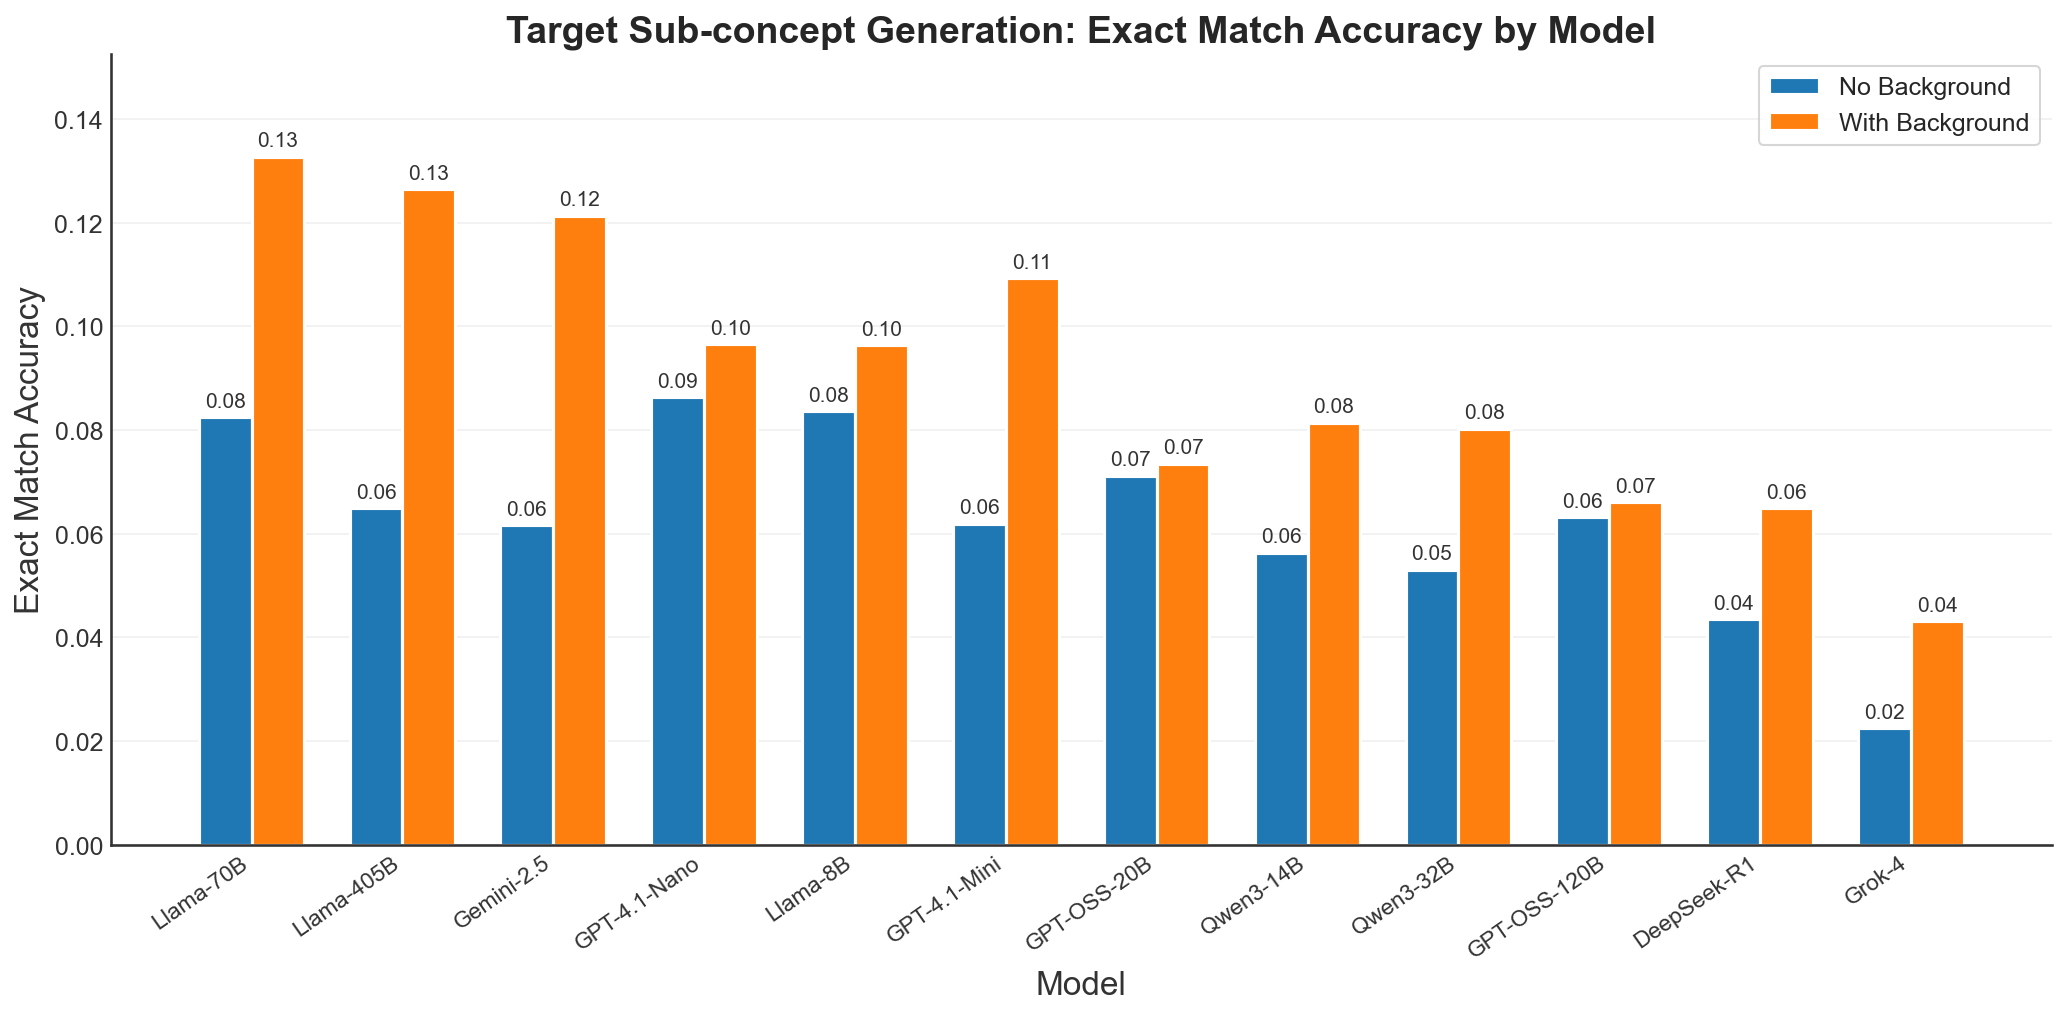

✅ Saved: results\visualizations_property_extraction\exact_match_accuracy_by_model_condition.png


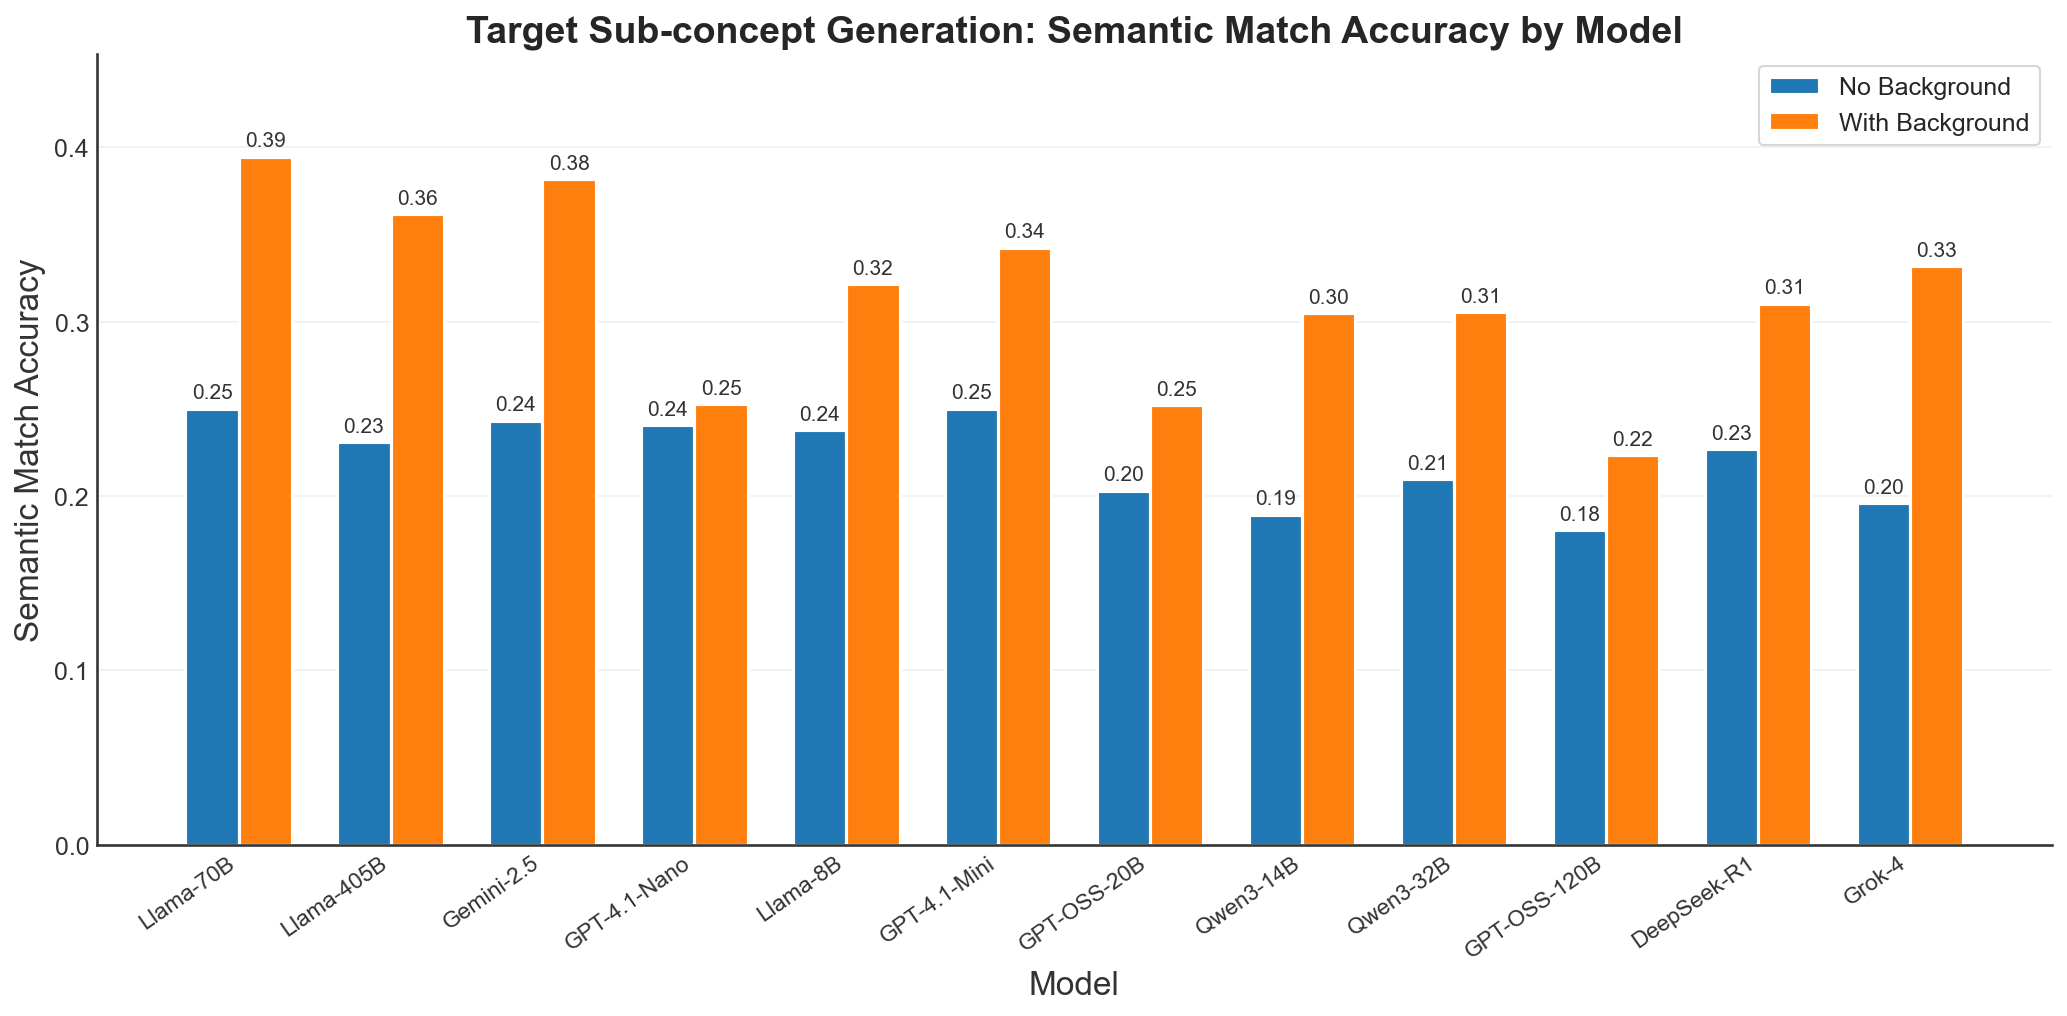

✅ Saved: results\visualizations_property_extraction\semantic_match_accuracy_by_model_condition.png

✅ Property Extraction Visualizations Complete!

Saved to: results\visualizations_property_extraction/
  • exact_match_accuracy_by_model_condition.png
  • semantic_match_accuracy_by_model_condition.png


In [9]:
# =============================================================================
# VISUALIZATION: Exact Match & Semantic Match Accuracy - Property Extraction 1a/1b
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams
import os

# =============================================================================
# Project Color Palette (Matching Chart Style)
# =============================================================================
COLORS = {
    'primary': '#1f77b4',      # Steel Blue
    'secondary': '#ff7f0e',    # Coral Orange
    'accent1': '#2ca02c',      # Green
    'accent2': '#d62728',      # Red
    'dark': '#9467bd',         # Purple
    'text': '#333333',         # Dark Gray
}

PALETTE_MAIN = [COLORS['primary'], COLORS['secondary'], COLORS['accent1'], 
                COLORS['accent2'], COLORS['dark'], '#8c564b', '#e377c2']

# Model Name Shortening
MODEL_SHORT_NAMES = {
    'gpt-oss-20b': 'GPT-OSS-20B',
    'gpt-oss-120b': 'GPT-OSS-120B',
    'gpt-4.1-mini': 'GPT-4.1-Mini',
    'gpt-4.1-nano': 'GPT-4.1-Nano',
    'grok-4-fast': 'Grok-4',
    'gemini-2.5-flash-lite': 'Gemini-2.5',
    'llama-3.1-405b-instruct': 'Llama-405B',
    'meta-llama-3-1-70b-instruct': 'Llama-70B',
    'meta-llama-3-1-8b-instruct': 'Llama-8B',
    'deepseek-r1': 'DeepSeek-R1',
    'qwen3-14b': 'Qwen3-14B',
    'qwen3-32b': 'Qwen3-32B',
}

# Set matplotlib style
plt.style.use('seaborn-v0_8-white')
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
rcParams['font.size'] = 14
rcParams['axes.labelsize'] = 16
rcParams['axes.titlesize'] = 18
rcParams['axes.titleweight'] = 'bold'
rcParams['axes.labelcolor'] = COLORS['text']
rcParams['axes.edgecolor'] = COLORS['text']
rcParams['xtick.color'] = COLORS['text']
rcParams['ytick.color'] = COLORS['text']
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['legend.fontsize'] = 12
rcParams['figure.dpi'] = 150
rcParams['savefig.dpi'] = 300
rcParams['savefig.bbox'] = 'tight'
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False

# =============================================================================
# Load Data
# =============================================================================
base_dir = "results"
df_no_desc = pd.read_csv(os.path.join(base_dir, "1a_property_extraction_no_desc.csv"))
df_with_desc = pd.read_csv(os.path.join(base_dir, "1b_property_extraction_with_desc.csv"))

# Add condition labels
df_no_desc['condition'] = 'No Description'
df_with_desc['condition'] = 'With Description'

# Combine dataframes
df_combined = pd.concat([df_no_desc, df_with_desc], ignore_index=True)

# Apply short model names
df_combined['model_short'] = df_combined['model'].map(MODEL_SHORT_NAMES)

# Calculate mean metrics per model per condition
summary = df_combined.groupby(['model_short', 'condition']).agg({
    'exact_match_accuracy': 'mean',
    'semantic_match_accuracy': 'mean'
}).reset_index()

# Get unique models sorted by overall performance
model_order = summary.groupby('model_short')['exact_match_accuracy'].mean().sort_values(ascending=False).index.tolist()

# Output directory
out_dir = os.path.join(base_dir, "visualizations_property_extraction")
os.makedirs(out_dir, exist_ok=True)

# =============================================================================
# Chart 1: Exact Match Accuracy by Model and Condition
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(14, 7))

x = np.arange(len(model_order))
width = 0.35

# Get data for each condition
no_desc_exact = []
with_desc_exact = []
for model in model_order:
    no_desc_val = summary[(summary['model_short'] == model) & (summary['condition'] == 'No Description')]['exact_match_accuracy'].values
    with_desc_val = summary[(summary['model_short'] == model) & (summary['condition'] == 'With Description')]['exact_match_accuracy'].values
    no_desc_exact.append(no_desc_val[0] if len(no_desc_val) > 0 else 0)
    with_desc_exact.append(with_desc_val[0] if len(with_desc_val) > 0 else 0)

bars1 = ax1.bar(x - width/2, no_desc_exact, width, label='No Background', 
                color=COLORS['primary'], edgecolor='white', linewidth=1.5)
bars2 = ax1.bar(x + width/2, with_desc_exact, width, label='With Background', 
                color=COLORS['secondary'], edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, color=COLORS['text'])

for bar in bars2:
    height = bar.get_height()
    ax1.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, color=COLORS['text'])

ax1.set_xlabel('Model', fontsize=16)
ax1.set_ylabel('Exact Match Accuracy', fontsize=16)
ax1.set_title('Target Sub-concept Generation: Exact Match Accuracy by Model', fontsize=18, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(model_order, rotation=35, ha='right', fontsize=11)
ax1.set_ylim(0, max(max(no_desc_exact), max(with_desc_exact)) * 1.15)
ax1.legend(loc='upper right', frameon=True, fancybox=True)
ax1.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig1.savefig(os.path.join(out_dir, "exact_match_accuracy_by_model_condition.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {os.path.join(out_dir, 'exact_match_accuracy_by_model_condition.png')}")

# =============================================================================
# Chart 2: Semantic Match Accuracy by Model and Condition (Threshold 0.7)
# =============================================================================
fig2, ax2 = plt.subplots(figsize=(14, 7))

# Get data for each condition
no_desc_semantic = []
with_desc_semantic = []
for model in model_order:
    no_desc_val = summary[(summary['model_short'] == model) & (summary['condition'] == 'No Description')]['semantic_match_accuracy'].values
    with_desc_val = summary[(summary['model_short'] == model) & (summary['condition'] == 'With Description')]['semantic_match_accuracy'].values
    no_desc_semantic.append(no_desc_val[0] if len(no_desc_val) > 0 else 0)
    with_desc_semantic.append(with_desc_val[0] if len(with_desc_val) > 0 else 0)

bars3 = ax2.bar(x - width/2, no_desc_semantic, width, label='No Background', 
                color=COLORS['primary'], edgecolor='white', linewidth=1.5)
bars4 = ax2.bar(x + width/2, with_desc_semantic, width, label='With Background', 
                color=COLORS['secondary'], edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar in bars3:
    height = bar.get_height()
    ax2.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, color=COLORS['text'])

for bar in bars4:
    height = bar.get_height()
    ax2.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, color=COLORS['text'])

ax2.set_xlabel('Model', fontsize=16)
ax2.set_ylabel('Semantic Match Accuracy', fontsize=16)
ax2.set_title('Target Sub-concept Generation: Semantic Match Accuracy by Model', fontsize=18, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(model_order, rotation=35, ha='right', fontsize=11)
ax2.set_ylim(0, max(max(no_desc_semantic), max(with_desc_semantic)) * 1.15)
ax2.legend(loc='upper right', frameon=True, fancybox=True)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig2.savefig(os.path.join(out_dir, "semantic_match_accuracy_by_model_condition.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {os.path.join(out_dir, 'semantic_match_accuracy_by_model_condition.png')}")

print("\n" + "="*70)
print("✅ Property Extraction Visualizations Complete!")
print("="*70)
print(f"\nSaved to: {out_dir}/")
print("  • exact_match_accuracy_by_model_condition.png")
print("  • semantic_match_accuracy_by_model_condition.png")

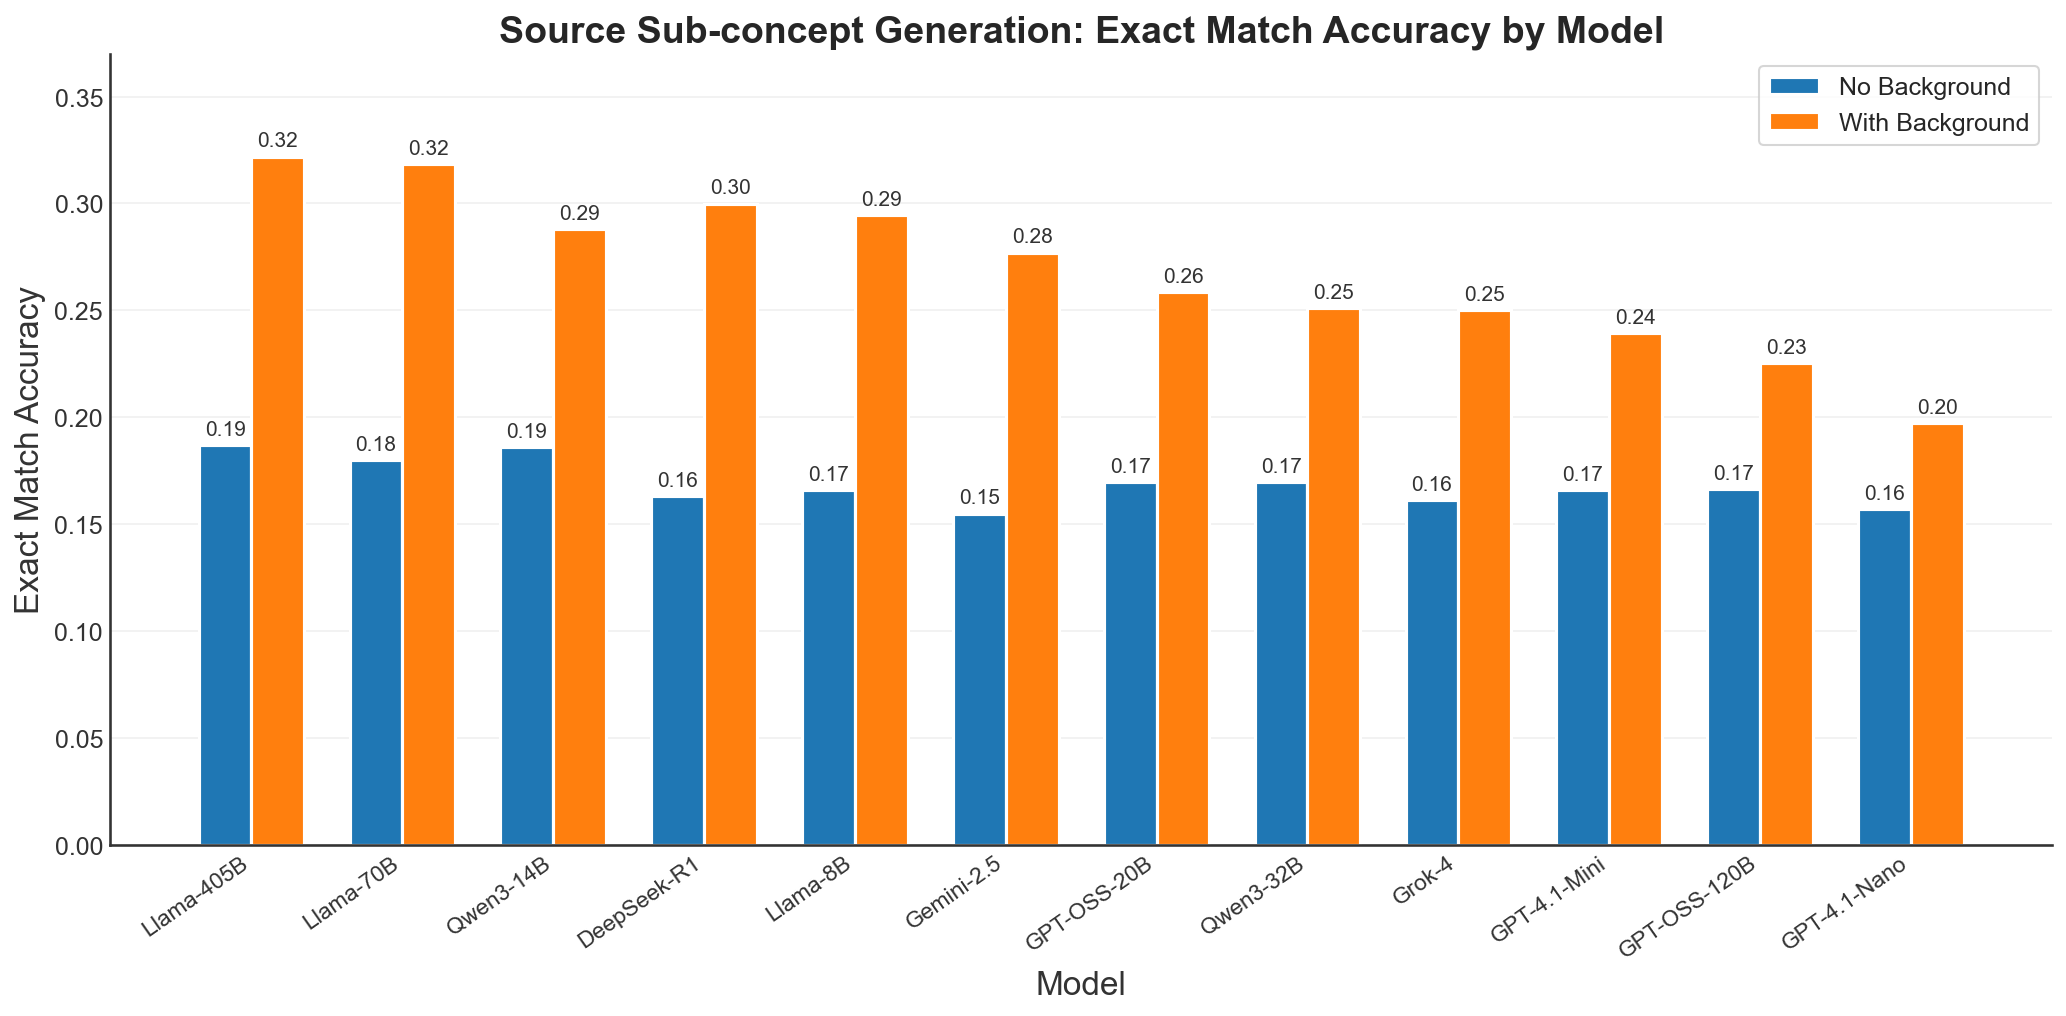

✅ Saved: results\visualizations_source_mapping\source_exact_match_accuracy_by_model_condition.png


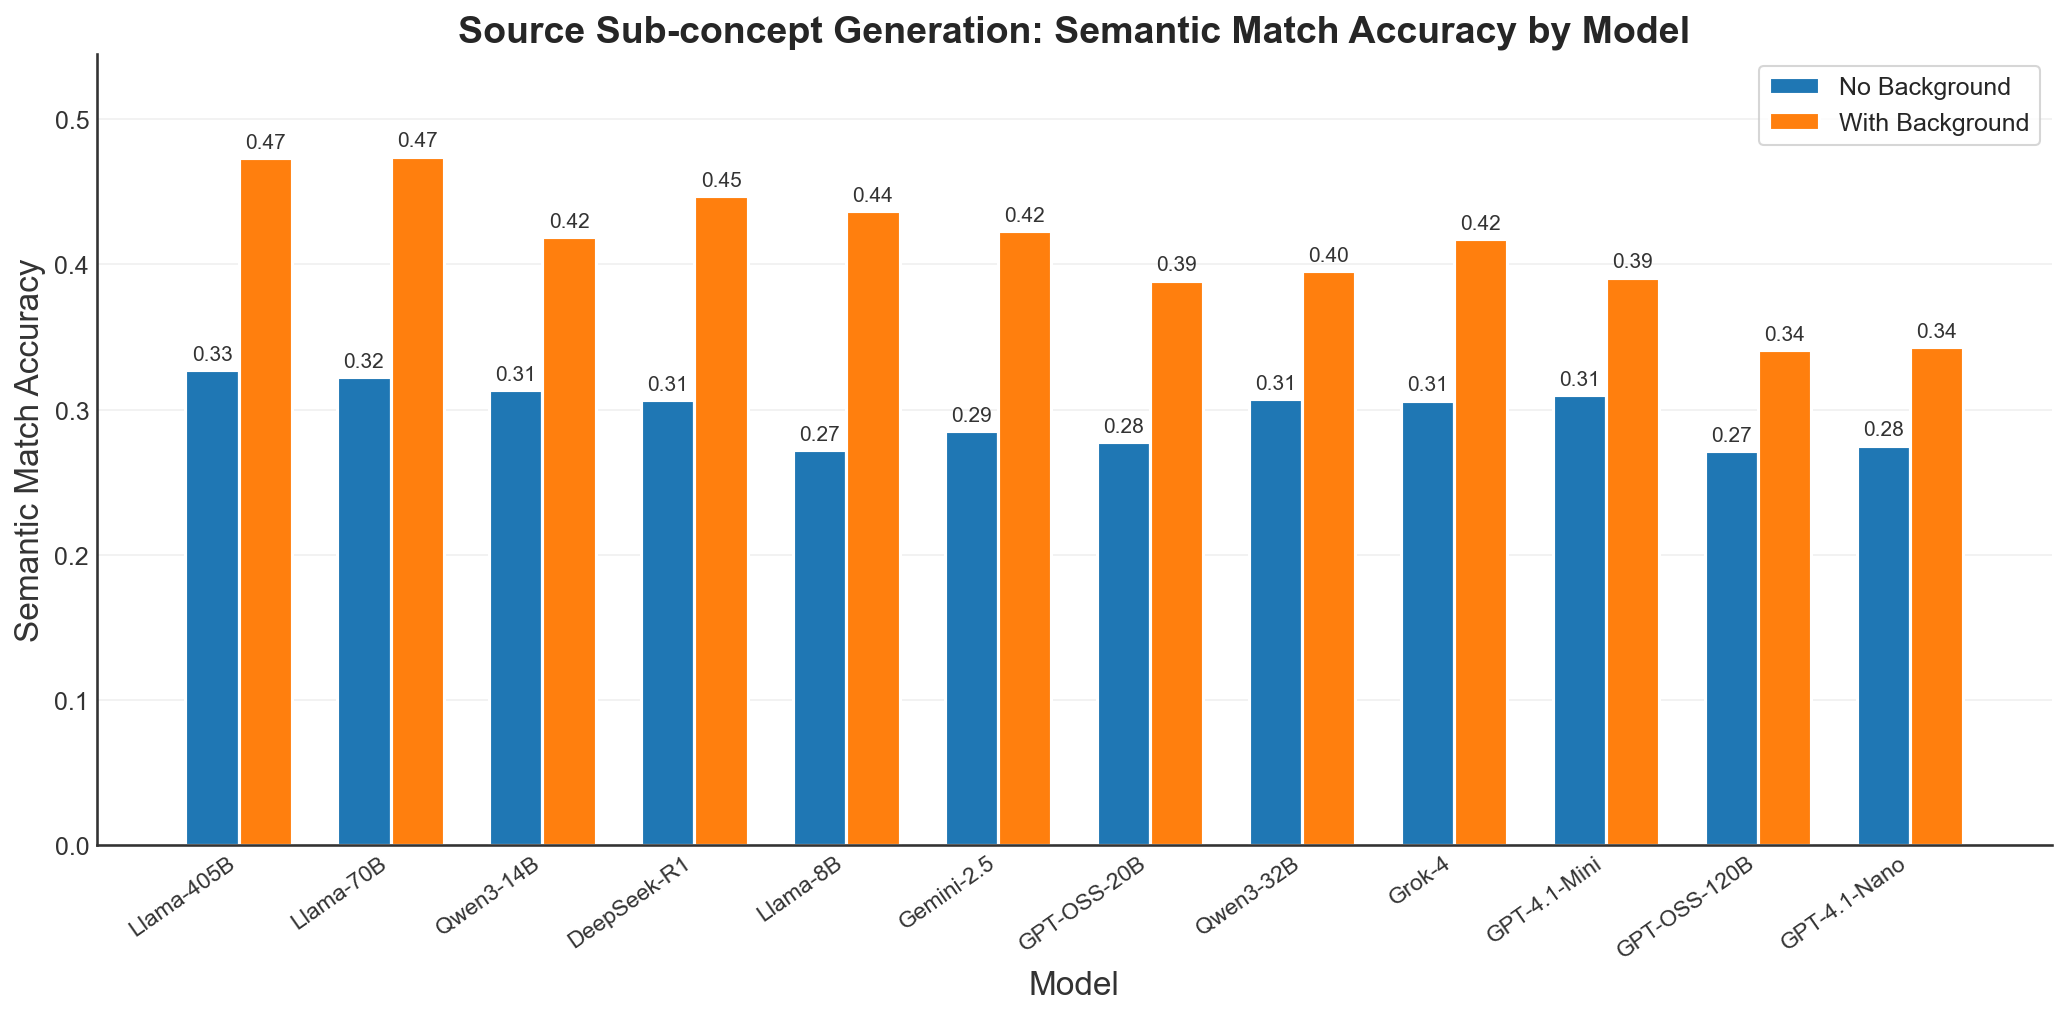

✅ Saved: results\visualizations_source_mapping\source_semantic_match_accuracy_by_model_condition.png

✅ Source Sub-concept Generation Visualizations Complete!

Saved to: results\visualizations_source_mapping/
  • source_exact_match_accuracy_by_model_condition.png
  • source_semantic_match_accuracy_by_model_condition.png


In [10]:
# =============================================================================
# VISUALIZATION: Source Sub-concept Generation - Exact & Semantic Match Accuracy
# =============================================================================

# =============================================================================
# Load Source Mapping Data
# =============================================================================
df_source_no_desc = pd.read_csv(os.path.join(base_dir, "2a_source_mapping_no_desc.csv"))
df_source_with_desc = pd.read_csv(os.path.join(base_dir, "2b_source_mapping_with_desc.csv"))

# Add condition labels
df_source_no_desc['condition'] = 'No Description'
df_source_with_desc['condition'] = 'With Description'

# Combine dataframes
df_source_combined = pd.concat([df_source_no_desc, df_source_with_desc], ignore_index=True)

# Apply short model names
df_source_combined['model_short'] = df_source_combined['model'].map(MODEL_SHORT_NAMES)

# Calculate mean metrics per model per condition
source_summary = df_source_combined.groupby(['model_short', 'condition']).agg({
    'source_prop_exact_match_accuracy': 'mean',
    'source_prop_semantic_match_accuracy': 'mean'
}).reset_index()

# Get unique models sorted by overall performance
source_model_order = source_summary.groupby('model_short')['source_prop_exact_match_accuracy'].mean().sort_values(ascending=False).index.tolist()

# Output directory
source_out_dir = os.path.join(base_dir, "visualizations_source_mapping")
os.makedirs(source_out_dir, exist_ok=True)

x_source = np.arange(len(source_model_order))

# =============================================================================
# Chart 1: Source Sub-concept Exact Match Accuracy by Model and Condition
# =============================================================================
fig3, ax3 = plt.subplots(figsize=(14, 7))

# Get data for each condition
source_no_desc_exact = []
source_with_desc_exact = []
for model in source_model_order:
    no_desc_val = source_summary[(source_summary['model_short'] == model) & (source_summary['condition'] == 'No Description')]['source_prop_exact_match_accuracy'].values
    with_desc_val = source_summary[(source_summary['model_short'] == model) & (source_summary['condition'] == 'With Description')]['source_prop_exact_match_accuracy'].values
    source_no_desc_exact.append(no_desc_val[0] if len(no_desc_val) > 0 else 0)
    source_with_desc_exact.append(with_desc_val[0] if len(with_desc_val) > 0 else 0)

bars5 = ax3.bar(x_source - width/2, source_no_desc_exact, width, label='No Background', 
                color=COLORS['primary'], edgecolor='white', linewidth=1.5)
bars6 = ax3.bar(x_source + width/2, source_with_desc_exact, width, label='With Background', 
                color=COLORS['secondary'], edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar in bars5:
    height = bar.get_height()
    ax3.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, color=COLORS['text'])

for bar in bars6:
    height = bar.get_height()
    ax3.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, color=COLORS['text'])

ax3.set_xlabel('Model', fontsize=16)
ax3.set_ylabel('Exact Match Accuracy', fontsize=16)
ax3.set_title('Source Sub-concept Generation: Exact Match Accuracy by Model', fontsize=18, fontweight='bold')
ax3.set_xticks(x_source)
ax3.set_xticklabels(source_model_order, rotation=35, ha='right', fontsize=11)
ax3.set_ylim(0, max(max(source_no_desc_exact), max(source_with_desc_exact)) * 1.15)
ax3.legend(loc='upper right', frameon=True, fancybox=True)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig3.savefig(os.path.join(source_out_dir, "source_exact_match_accuracy_by_model_condition.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {os.path.join(source_out_dir, 'source_exact_match_accuracy_by_model_condition.png')}")

# =============================================================================
# Chart 2: Source Sub-concept Semantic Match Accuracy by Model and Condition
# =============================================================================
fig4, ax4 = plt.subplots(figsize=(14, 7))

# Get data for each condition
source_no_desc_semantic = []
source_with_desc_semantic = []
for model in source_model_order:
    no_desc_val = source_summary[(source_summary['model_short'] == model) & (source_summary['condition'] == 'No Description')]['source_prop_semantic_match_accuracy'].values
    with_desc_val = source_summary[(source_summary['model_short'] == model) & (source_summary['condition'] == 'With Description')]['source_prop_semantic_match_accuracy'].values
    source_no_desc_semantic.append(no_desc_val[0] if len(no_desc_val) > 0 else 0)
    source_with_desc_semantic.append(with_desc_val[0] if len(with_desc_val) > 0 else 0)

bars7 = ax4.bar(x_source - width/2, source_no_desc_semantic, width, label='No Background', 
                color=COLORS['primary'], edgecolor='white', linewidth=1.5)
bars8 = ax4.bar(x_source + width/2, source_with_desc_semantic, width, label='With Background', 
                color=COLORS['secondary'], edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar in bars7:
    height = bar.get_height()
    ax4.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, color=COLORS['text'])

for bar in bars8:
    height = bar.get_height()
    ax4.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, color=COLORS['text'])

ax4.set_xlabel('Model', fontsize=16)
ax4.set_ylabel('Semantic Match Accuracy', fontsize=16)
ax4.set_title('Source Sub-concept Generation: Semantic Match Accuracy by Model', fontsize=18, fontweight='bold')
ax4.set_xticks(x_source)
ax4.set_xticklabels(source_model_order, rotation=35, ha='right', fontsize=11)
ax4.set_ylim(0, max(max(source_no_desc_semantic), max(source_with_desc_semantic)) * 1.15)
ax4.legend(loc='upper right', frameon=True, fancybox=True)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig4.savefig(os.path.join(source_out_dir, "source_semantic_match_accuracy_by_model_condition.png"), dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {os.path.join(source_out_dir, 'source_semantic_match_accuracy_by_model_condition.png')}")

print("\n" + "="*70)
print("✅ Source Sub-concept Generation Visualizations Complete!")
print("="*70)
print(f"\nSaved to: {source_out_dir}/")
print("  • source_exact_match_accuracy_by_model_condition.png")
print("  • source_semantic_match_accuracy_by_model_condition.png")

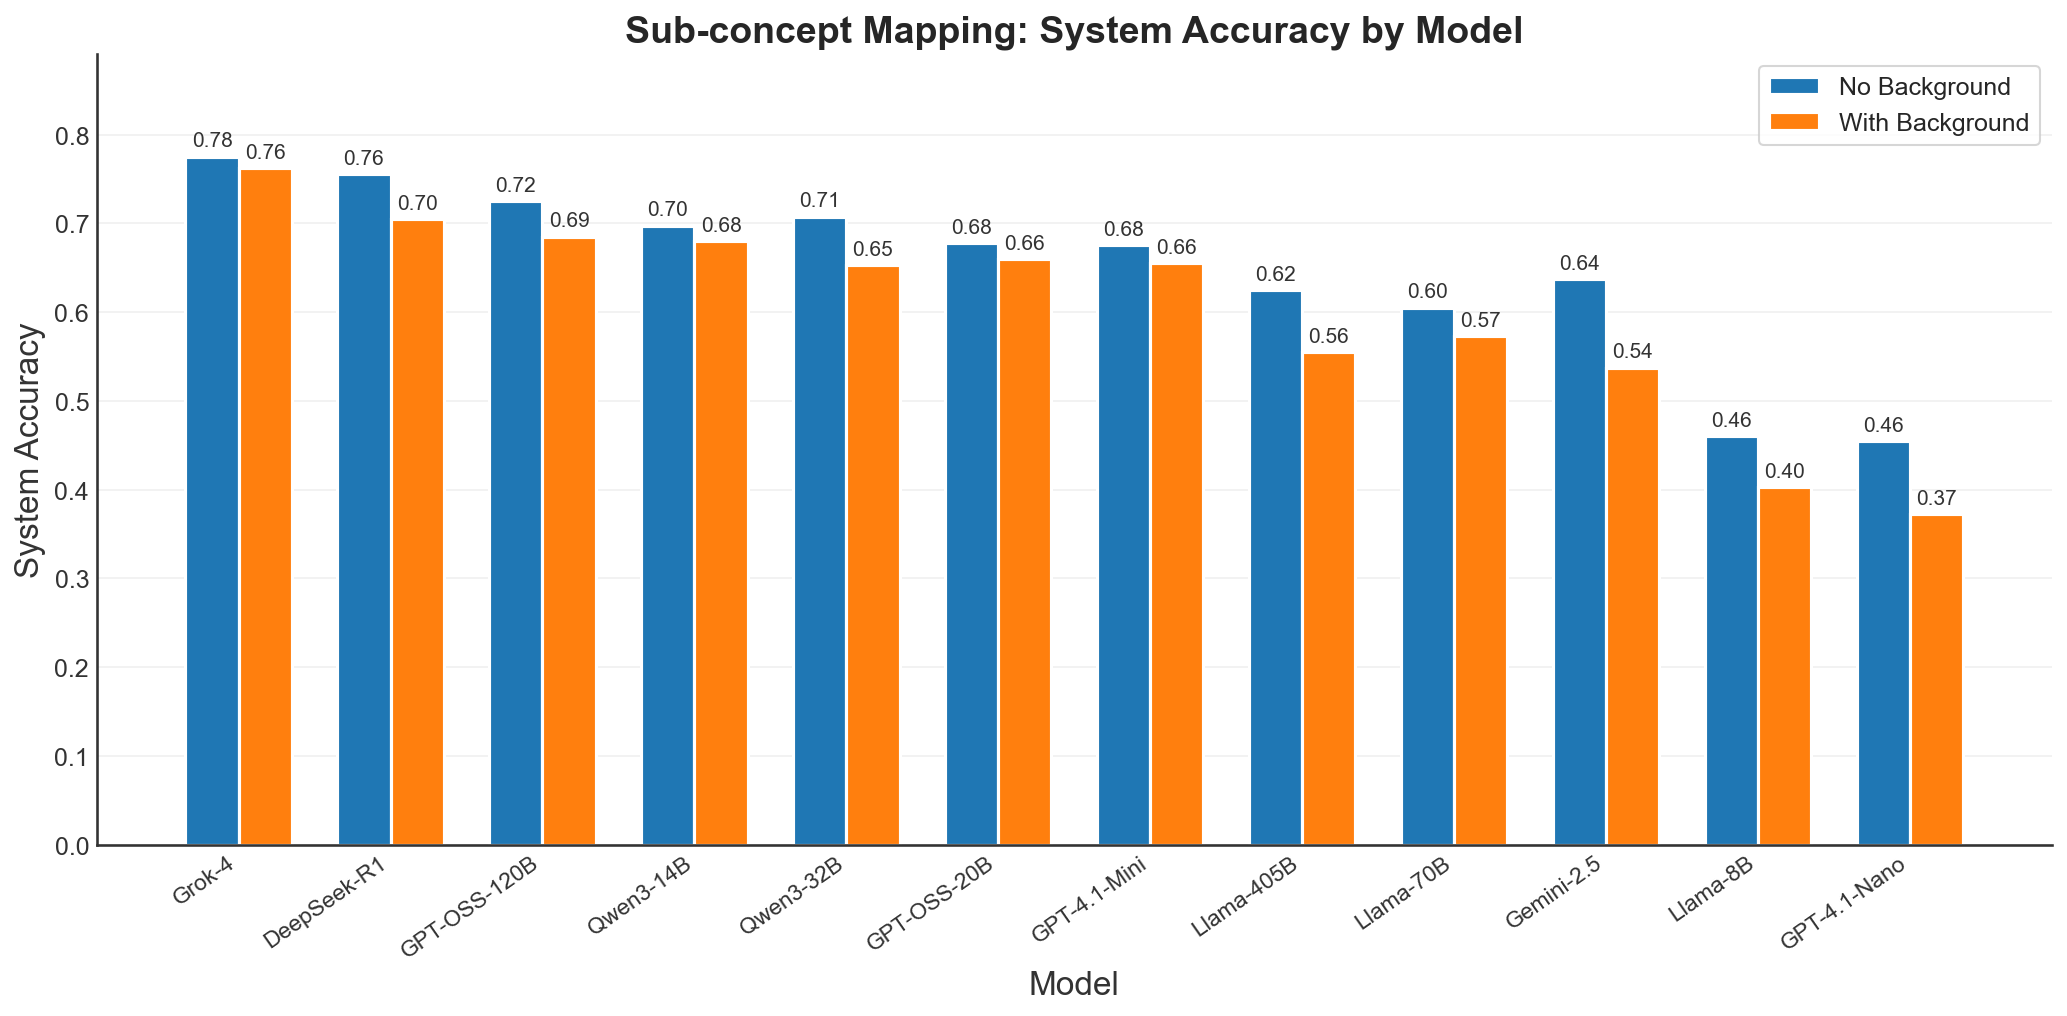

✅ Saved: results\visualizations_property_matching\system_accuracy_by_model_condition.png


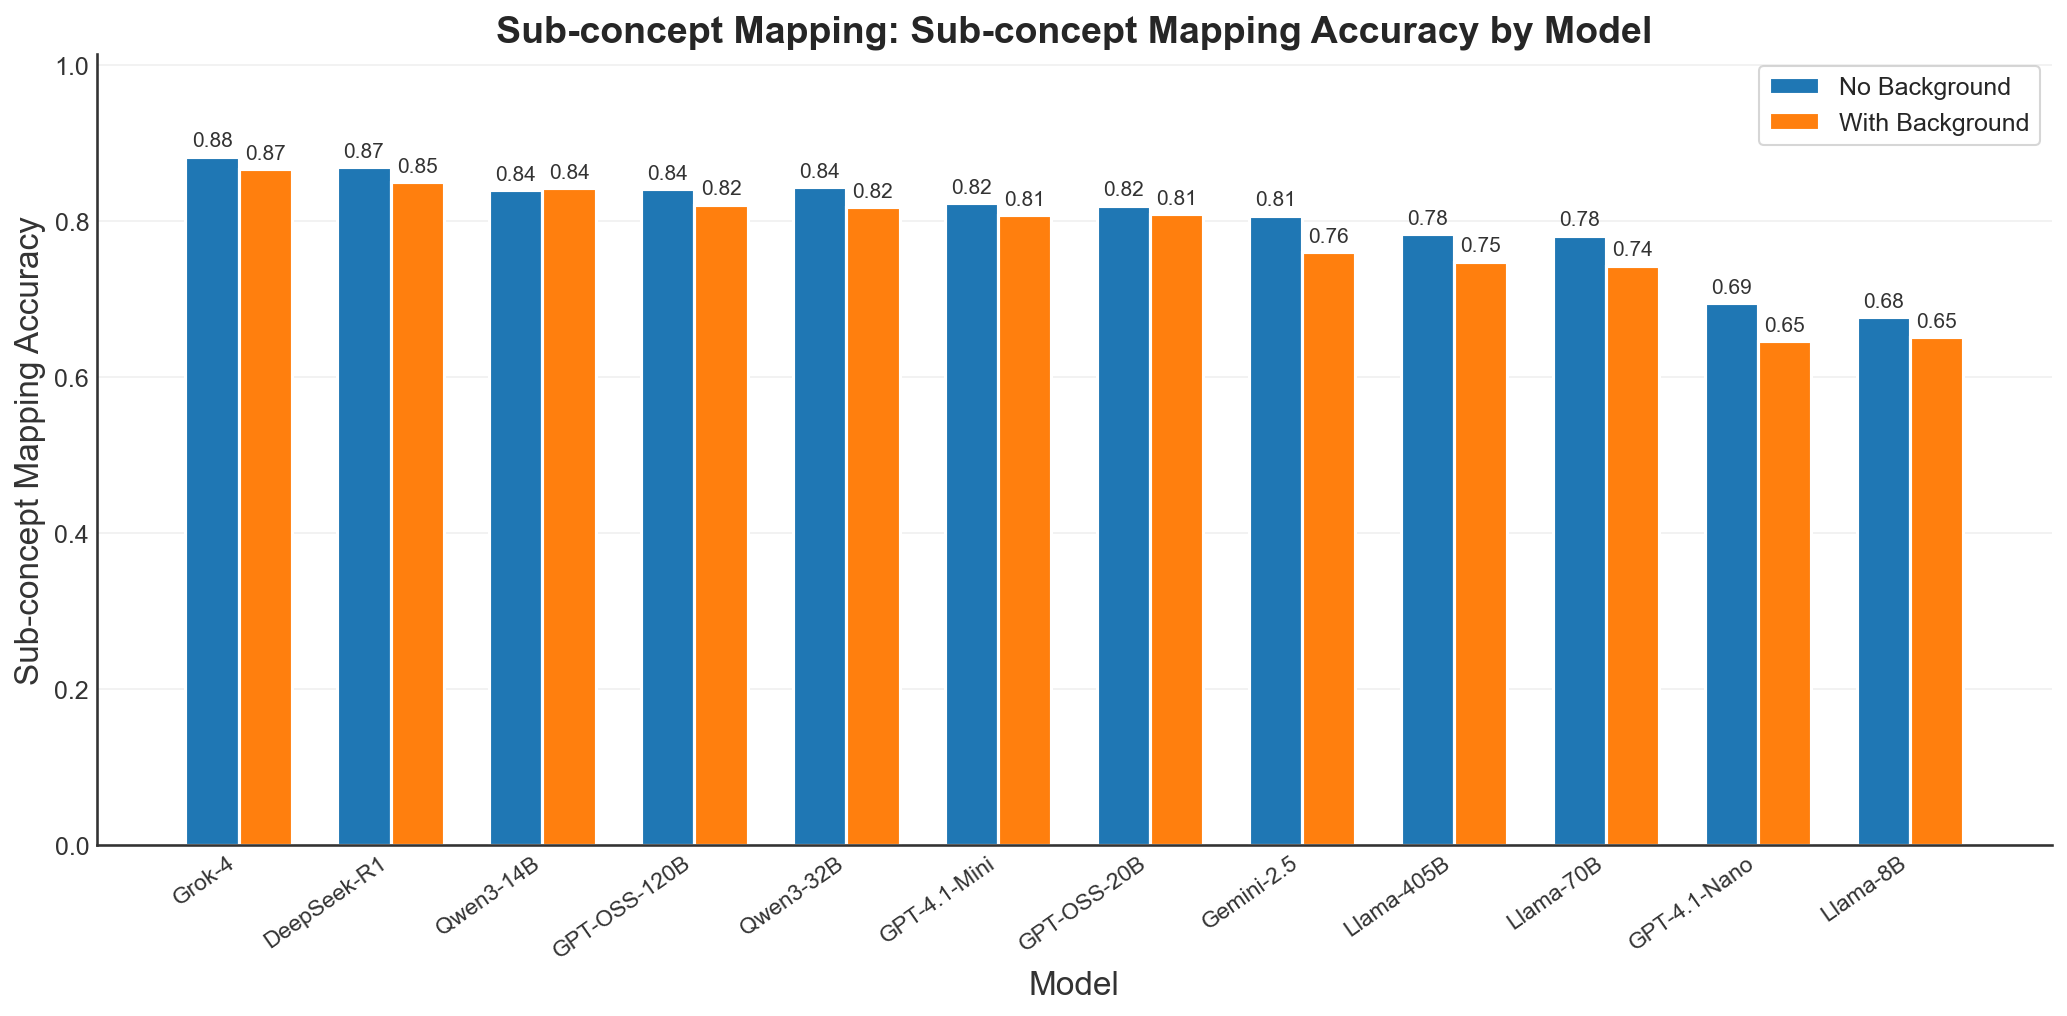

✅ Saved: results\visualizations_property_matching\concept_accuracy_by_model_condition.png

✅ Property Matching Visualizations Complete!

Saved to: results\visualizations_property_matching/
  • system_accuracy_by_model_condition.png
  • concept_accuracy_by_model_condition.png


In [14]:
# =============================================================================
# VISUALIZATION: Property Matching - System Accuracy & Concept Accuracy
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams
import os

# =============================================================================
# Project Color Palette (Matching Chart Style)
# =============================================================================
COLORS = {
    'primary': '#1f77b4',      # Steel Blue
    'secondary': '#ff7f0e',    # Coral Orange
    'accent1': '#2ca02c',      # Green
    'accent2': '#d62728',      # Red
    'dark': '#9467bd',         # Purple
    'text': '#333333',         # Dark Gray
}


# =============================================================================
# Model Name Mapping (for cleaner chart labels)
# =============================================================================
MODEL_NAMES = {
    'gpt-oss-20b': 'GPT-OSS-20B',
    'gpt-oss-120b': 'GPT-OSS-120B',
    'gpt-4.1-mini': 'GPT-4.1-Mini',
    'gpt-4.1-nano': 'GPT-4.1-Nano',
    'grok-4-fast': 'Grok-4',
    'gemini-2.5-flash-lite': 'Gemini-2.5',
    'llama-3.1-405b-instruct': 'Llama-405B',
    'meta-llama-3-1-70b-instruct': 'Llama-70B',
    'meta-llama-3-1-8b-instruct': 'Llama-8B',
    'deepseek-r1': 'DeepSeek-R1',
    'qwen3-14b': 'Qwen3-14B',
    'qwen3-32b': 'Qwen3-32B',
}

# =============================================================================
# Matplotlib Configuration
# =============================================================================
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False

# Base directory for results
base_dir = "results"

# =============================================================================
# Load Property Matching Data
# =============================================================================
df_match_no_desc = pd.read_csv(os.path.join(base_dir, "2c_property_matching_no_desc.csv"))
df_match_with_desc = pd.read_csv(os.path.join(base_dir, "2d_property_matching_with_desc.csv"))

# Add condition labels
df_match_no_desc['condition'] = 'No Description'
df_match_with_desc['condition'] = 'With Description'

# Combine dataframes
df_match_combined = pd.concat([df_match_no_desc, df_match_with_desc], ignore_index=True)

# =============================================================================
# Apply Model Name Mapping
# =============================================================================
df_match_combined['model_short'] = df_match_combined['model'].map(MODEL_NAMES)

# Fill any unmapped models with original names
df_match_combined['model_short'] = df_match_combined['model_short'].fillna(df_match_combined['model'])

# =============================================================================
# Calculate Aggregated Metrics
# =============================================================================
# System accuracy: convert boolean to numeric and calculate mean (proportion of True)
df_match_combined['system_accuracy_numeric'] = df_match_combined['system_accuracy'].astype(int)

# Group by model and condition, calculate mean accuracies
match_stats = df_match_combined.groupby(['model_short', 'condition']).agg({
    'system_accuracy_numeric': 'mean',
    'concept_mapping_accuracy': 'mean'
}).reset_index()

# Get unique models sorted by system_accuracy (highest first)
match_models_system = match_stats.groupby('model_short')['system_accuracy_numeric'].mean().sort_values(ascending=False).index.tolist()

# Get unique models sorted by concept_mapping_accuracy (highest first)
match_models_concept = match_stats.groupby('model_short')['concept_mapping_accuracy'].mean().sort_values(ascending=False).index.tolist()

# Prepare data for System Accuracy chart (sorted by system_accuracy)
match_no_desc_system = []
match_with_desc_system = []

for model in match_models_system:
    no_desc_sys = match_stats[(match_stats['model_short'] == model) & 
                              (match_stats['condition'] == 'No Description')]['system_accuracy_numeric'].values
    with_desc_sys = match_stats[(match_stats['model_short'] == model) & 
                                (match_stats['condition'] == 'With Description')]['system_accuracy_numeric'].values
    match_no_desc_system.append(no_desc_sys[0] if len(no_desc_sys) > 0 else 0)
    match_with_desc_system.append(with_desc_sys[0] if len(with_desc_sys) > 0 else 0)

# Prepare data for Concept Accuracy chart (sorted by concept_mapping_accuracy)
match_no_desc_concept = []
match_with_desc_concept = []

for model in match_models_concept:
    no_desc_concept = match_stats[(match_stats['model_short'] == model) & 
                                  (match_stats['condition'] == 'No Description')]['concept_mapping_accuracy'].values
    with_desc_concept = match_stats[(match_stats['model_short'] == model) & 
                                    (match_stats['condition'] == 'With Description')]['concept_mapping_accuracy'].values
    match_no_desc_concept.append(no_desc_concept[0] if len(no_desc_concept) > 0 else 0)
    match_with_desc_concept.append(with_desc_concept[0] if len(with_desc_concept) > 0 else 0)

# =============================================================================
# Create Output Directory
# =============================================================================
match_output_dir = os.path.join(base_dir, "visualizations_property_matching")
os.makedirs(match_output_dir, exist_ok=True)

# =============================================================================
# CHART 1: System Accuracy by Model (grouped by condition) - sorted by system_accuracy
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(14, 7))

x_system = np.arange(len(match_models_system))
width = 0.35

bars1 = ax1.bar(x_system - width/2, match_no_desc_system, width, label='No Background', 
                color=COLORS['primary'], edgecolor='white', linewidth=1.5)
bars2 = ax1.bar(x_system + width/2, match_with_desc_system, width, label='With Background', 
                color=COLORS['secondary'], edgecolor='white', linewidth=1.5)

ax1.set_xlabel('Model', fontsize=16)
ax1.set_ylabel('System Accuracy', fontsize=16)
ax1.set_title('Sub-concept Mapping: System Accuracy by Model', fontsize=18, fontweight='bold')
ax1.set_xticks(x_system)
ax1.set_xticklabels(match_models_system, rotation=35, ha='right', fontsize=11)
ax1.legend(loc='upper right', frameon=True, fancybox=True)
ax1.set_ylim(0, max(max(match_no_desc_system), max(match_with_desc_system)) * 1.15)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, color=COLORS['text'])

for bar in bars2:
    height = bar.get_height()
    ax1.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, color=COLORS['text'])

plt.tight_layout()
fig1.savefig(os.path.join(match_output_dir, 'system_accuracy_by_model_condition.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {os.path.join(match_output_dir, 'system_accuracy_by_model_condition.png')}")

# =============================================================================
# CHART 2: Concept Mapping Accuracy by Model (grouped by condition) - sorted by concept_mapping_accuracy
# =============================================================================
fig2, ax2 = plt.subplots(figsize=(14, 7))

x_concept = np.arange(len(match_models_concept))

bars3 = ax2.bar(x_concept - width/2, match_no_desc_concept, width, label='No Background', 
                color=COLORS['primary'], edgecolor='white', linewidth=1.5)
bars4 = ax2.bar(x_concept + width/2, match_with_desc_concept, width, label='With Background', 
                color=COLORS['secondary'], edgecolor='white', linewidth=1.5)

ax2.set_xlabel('Model', fontsize=16)
ax2.set_ylabel('Sub-concept Mapping Accuracy', fontsize=16)
ax2.set_title('Sub-concept Mapping: Sub-concept Mapping Accuracy by Model', fontsize=18, fontweight='bold')
ax2.set_xticks(x_concept)
ax2.set_xticklabels(match_models_concept, rotation=35, ha='right', fontsize=11)
ax2.legend(loc='upper right', frameon=True, fancybox=True)
ax2.set_ylim(0, max(max(match_no_desc_concept), max(match_with_desc_concept)) * 1.15)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars3:
    height = bar.get_height()
    ax2.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, color=COLORS['text'])

for bar in bars4:
    height = bar.get_height()
    ax2.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, color=COLORS['text'])

plt.tight_layout()
fig2.savefig(os.path.join(match_output_dir, 'concept_accuracy_by_model_condition.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {os.path.join(match_output_dir, 'concept_accuracy_by_model_condition.png')}")

print("\n" + "="*70)
print("✅ Property Matching Visualizations Complete!")
print("="*70)
print(f"\nSaved to: {match_output_dir}/")
print("  • system_accuracy_by_model_condition.png")
print("  • concept_accuracy_by_model_condition.png")

### `Source Finding then Mapping`
❓The System accuracy is good? can the models find all mappings correct?

❓ If not are they at least close embedding wise?

❓Which models are best?

In [1]:
from source_mapping_viz import generate_source_mapping_visuals

generate_source_mapping_visuals(
    base_dir="results",
    file_names=[
        "2a_source_mapping_no_desc.csv",
        "2b_source_mapping_with_desc.csv",
    ],
    out_subfolder="visualizations_source_mapping2"
)

{'out_dir': 'results\\visualizations_source_mapping2',
 'tidy_csv': 'results\\visualizations_source_mapping2\\tidy_source_mapping_summary.csv'}

### `Property Matching`
❓The system and concept accuracy?

❓ Is there outside words found that has no matches?

❓Which models are best at matching?

In [2]:
from property_matching_viz import generate_property_matching_visuals

generate_property_matching_visuals(
    base_dir="results",
    file_names=["2c_property_matching_no_desc.csv", "2d_property_matching_with_desc.csv"],
    out_subfolder="visualizations_property_matching"
)

{'out_dir': 'results\\visualizations_property_matching',
 'tidy_csv': 'results\\visualizations_property_matching\\tidy_property_matching_summary.csv'}

## Fixing the not having shuffled